# Opioid Dose, Opioid Type, and 48-Hour Mortality in Hospitalized Cancer Patients

**Goal**: among cancer patients admitted to the hospital and given an
opioid analgesic, does the *dose* (and *type*) of opioid predict mortality in the following
48 hours, once we control for how sick the patient already was at the time of the dose?

This notebook is the modeling stage of the pipeline. The cohort-building and feature-engineering
work already happened in `../Defining Cohort/` (cohort selection, drug/MME parsing, SOFA scoring,
outcome windows, comorbidities, cancer typing). Here we:

1. Load the **dose-level** analysis table (`dose_level_df.parquet`) — one row per opioid order,
   with a pre-dose severity snapshot and a forward-looking mortality label.
2. Define the prediction target and explicitly exclude columns that would leak the outcome.
3. Split by **patient**, not by dose, so the same person's doses can't appear in both train and test.
4. Fit an interpretable baseline (logistic regression) to read off the dose/opioid-type effect
   sizes controlling for severity, then a more flexible model (gradient boosting) for predictive
   performance.
5. Evaluate with metrics appropriate for a rare event (~3-4% of doses), and visualize how
   predicted risk moves with dose, separately by opioid type.



In [3]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix,
)

import matplotlib.pyplot as plt

RANDOM_STATE = 7
pd.set_option("display.max_columns", 100)


In [4]:
DATA_PATH = "../Defining Cohort/dose_level_df.parquet"

dose_df = pd.read_parquet(DATA_PATH)

print(f"Doses: {len(dose_df):,}  |  admissions: {dose_df.hadm_id.nunique():,}  |  patients: {dose_df.subject_id.nunique():,}")
print(f"died_within_48h rate: {dose_df['died_within_48h'].mean():.2%}  ({dose_df['died_within_48h'].sum():,} doses)")


Doses: 153,232  |  admissions: 43,914  |  patients: 22,019
died_within_48h rate: 3.64%  (5,572 doses)


## Target and feature selection

**Target:** `died_within_48h` — did the patient die within 48 hours of *this* opioid dose.
`dose_level_df` also has 6h/12h/24h versions of the same label; we focus on 48h (per the stated
goal) and revisit the shorter horizons later as a robustness check, not as features.

**Columns excluded from the feature matrix, and why:**

| Group | Columns | Reason |
|---|---|---|
| Identifiers / raw timestamps | `dose_id`, `subject_id`, `hadm_id`, `starttime`, `stoptime` | Not predictive signal; timestamps are already summarized into the engineered features below |
| Raw/duplicate drug fields | `drug`, `dose_val_rx`, `dose_unit_rx`, `dose_numeric`, `mme_factor` | Superseded by the cleaned `opioid_type` + `mme_dose` (MME-standardized) columns |
| Constant | `exposed`, `implausible_patch_rate` | `exposed` is always `True` by cohort construction. `implausible_patch_rate` flagged the one fentanyl-patch data-entry error (5625 mcg/h -> 324,000 MME) upstream in `cohort_drug_features.ipynb`, but that flag also zeroed out `mme_factor` for the flagged row(s), which then get dropped by the `dropna(subset=["dose_numeric","mme_factor"])` a few lines later -- so every row that survives into this table has `implausible_patch_rate == False`. It's a useful audit trail in `cohort_drug_features.ipynb`, not a feature here. |
| Duplicate | `anchor_age` | Same information as `age_at_admission`, kept once |
| **Outcome-defining** | `deathtime`, `dod`, `death_reference_time`, `hours_to_death` | These are literally how the label was computed |
| **Other-horizon labels** | `died_within_6h`, `died_within_12h`, `died_within_24h` | Near-perfectly correlated with `died_within_48h` (a 6h death is also a 48h death) — including them would leak the target |
| **Secondary outcome** | `naloxone_within_6h`, `naloxone_within_12h` | An opioid-toxicity *outcome* of the dose, not a pre-dose covariate — using it as a predictor would condition on a post-treatment variable |

**Severity control:** rather than feeding in every raw pre-dose vital/lab (`spo2_pre_dose`,
`gcs_eye_pre_dose`, ... ) *and* the SOFA components computed from them, we use the composite
`sofa_total_pre_dose` (plus `n_sofa_components_missing_pre_dose`, since SOFA is frequently
computed from a partial component set for non-ICU doses — see the note in
`cohort_lab_features.ipynb`) as the primary severity control. This avoids feeding the same
clinical signal into the model twice through collinear raw + derived columns. The individual
SOFA components are still in `dose_level_df`.


In [5]:
TARGET = "died_within_48h"

id_and_raw_cols = [
    "dose_id", "subject_id", "hadm_id", "starttime", "stoptime",
    "drug", "dose_val_rx", "dose_unit_rx", "dose_numeric", "mme_factor",
]
# constant in this table -- see markdown above for why implausible_patch_rate ends up constant
constant_cols = ["exposed", "implausible_patch_rate"]
outcome_leakage_cols = [
    "deathtime", "dod", "death_reference_time", "hours_to_death",
    "died_within_6h", "died_within_12h", "died_within_24h",
    "naloxone_within_6h", "naloxone_within_12h",
]
# individual pre-dose vitals/SOFA sub-components, superseded by sofa_total_pre_dose (see markdown above)
redundant_severity_cols = [
    "spo2_pre_dose", "fio2_pre_dose", "map_pre_dose", "map_cuff_pre_dose",
    "gcs_eye_pre_dose", "gcs_verbal_pre_dose", "gcs_motor_pre_dose",
    "platelets_pre_dose", "bilirubin_pre_dose", "creatinine_pre_dose",
    "map_pre_dose_worst", "gcs_total_pre_dose", "fio2_fraction_pre_dose", "spo2_fio2_ratio_pre_dose",
    "sofa_respiration_pre_dose", "sofa_coagulation_pre_dose", "sofa_liver_pre_dose",
    "sofa_cardiovascular_pre_dose", "sofa_cns_pre_dose", "sofa_renal_pre_dose",
]

drop_cols = set(id_and_raw_cols + constant_cols + outcome_leakage_cols + redundant_severity_cols + ["anchor_age", TARGET])
feature_cols = [c for c in dose_df.columns if c not in drop_cols]

categorical_features = ["opioid_type", "route", "gender", "insurance", "race", "language"]
numeric_features = [c for c in feature_cols if c not in categorical_features]

# sanity check: constant_cols really are constant post-cleaning, so dropping them loses no signal
for c in constant_cols:
    assert dose_df[c].nunique() == 1, f"{c} is not actually constant -- re-check before dropping it"

print(f"{len(feature_cols)} features: {len(numeric_features)} numeric/boolean, {len(categorical_features)} categorical")
print()
print("numeric/boolean:", numeric_features)
print()
print("categorical:    ", categorical_features)


42 features: 36 numeric/boolean, 6 categorical

numeric/boolean: ['mme_dose', 'prior_opioid_orders', 'opioid_naive', 'in_icu_hadm', 'mechanically_ventilated_at_dose', 'received_vasopressors_at_dose', 'sofa_total_pre_dose', 'n_sofa_components_missing_pre_dose', 'sedative_active_at_dose', 'prior_sedative_orders', 'cumulative_mme_prior_doses', 'n_prior_opioid_doses_this_admission', 'age_at_admission', 'has_diabetes', 'has_renal_disease', 'has_liver_disease', 'has_copd', 'has_substance_use_disorder', 'has_palliative_icd', 'any_palliative_signal', 'has_metastatic_disease', 'cancer_head_neck', 'cancer_gi', 'cancer_lung_thoracic', 'cancer_bone_softtissue', 'cancer_skin_melanoma', 'cancer_breast', 'cancer_gu', 'cancer_renal_bladder', 'cancer_cns', 'cancer_endocrine', 'cancer_heme_lymphoma', 'cancer_metastatic_unspecified', 'n_cancer_types_flagged', 'n_icu_stays', 'had_icu_stay']

categorical:     ['opioid_type', 'route', 'gender', 'insurance', 'race', 'language']


## Train/test split — grouped by patient

Doses within the same admission (and patients with multiple admissions) are not independent —
a plain random split would let doses from the same person leak into both train and test,
inflating apparent performance. We split on `subject_id` with `GroupShuffleSplit` so every dose
from a given patient lands entirely in train or entirely in test.


In [6]:
X = dose_df[feature_cols].copy()
y = dose_df[TARGET].astype(int).copy()
groups = dose_df["subject_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

assert set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]) == set()  # no patient overlap

print(f"Train: {len(X_train):,} doses, {groups_train.nunique():,} patients, {y_train.mean():.2%} died_within_48h")
print(f"Test:  {len(X_test):,} doses, {groups.iloc[test_idx].nunique():,} patients, {y_test.mean():.2%} died_within_48h")


Train: 114,874 doses, 16,514 patients, 3.61% died_within_48h
Test:  38,358 doses, 5,505 patients, 3.71% died_within_48h


## Preprocessing

- **Numeric/boolean features:** median-impute (the count-type features were already filled with
  0 upstream; this is a safety net for anything with residual missingness), then standardize.
- **Categorical features:** most-frequent-impute, then one-hot encode (`handle_unknown="ignore"`
  so the pipeline doesn't break on a category unseen in training, e.g. a rare `opioid_type`).

This replaces `KNNImputer(n_neighbors=100)` — with only ~3 columns having any
real missingness after the upstream fillna steps, a distance-based imputer over the whole feature
space isn't buying anything over median imputation, and it's far cheaper to fit/transform.


In [7]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])


## Baseline model: logistic regression

Interpretable starting point. `class_weight="balanced"` compensates for the ~3-4% event rate. We do this to make sure the model is not inflated because of our class imbalance (accuracy will not a good representation because the model could just predict "survives" and it will be correct >90% of the time).



In [8]:
logreg_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
logreg_pipe.fit(X_train, y_train)

logreg_test_proba = logreg_pipe.predict_proba(X_test)[:, 1]
print(f"Logistic regression -- ROC-AUC: {roc_auc_score(y_test, logreg_test_proba):.3f}  "
      f"PR-AUC: {average_precision_score(y_test, logreg_test_proba):.3f}")
print()
print(classification_report(y_test, logreg_test_proba > 0.5, target_names=["survived_48h", "died_within_48h"]))


Logistic regression -- ROC-AUC: 0.935  PR-AUC: 0.501

                 precision    recall  f1-score   support

   survived_48h       0.99      0.87      0.93     36936
died_within_48h       0.21      0.85      0.33      1422

       accuracy                           0.87     38358
      macro avg       0.60      0.86      0.63     38358
   weighted avg       0.96      0.87      0.91     38358



## Reading the dose / opioid-type effect

Coefficients are on the standardized-numeric / one-hot scale, so they're comparable to each
other in magnitude. Exponentiating gives an odds ratio: e.g. an odds ratio of 1.2 for `mme_dose`
means a one-standard-deviation increase in dose is associated with 20% higher odds of dying
within 48h, *holding `sofa_total_pre_dose` and the other covariates fixed*. Opioid-type
coefficients are each relative to whichever category `OneHotEncoder` drops implicitly (baseline
category), so compare them to each other and to zero, not to an absolute reference.


In [9]:
feature_names = preprocessor.get_feature_names_out()
coefs = logreg_pipe.named_steps["model"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coefs})
    .assign(odds_ratio=lambda d: np.exp(d["coef"]))
    .sort_values("coef", key=np.abs, ascending=False)
)

print("Top 15 features by |coefficient|:")
print(coef_df.head(15).to_string(index=False))

print()
print("Dose and opioid-type rows specifically:")
mask = coef_df["feature"].str.contains("mme_dose|opioid_type|sofa_total_pre_dose")
print(coef_df[mask].to_string(index=False))


Top 15 features by |coefficient|:
                              feature      coef  odds_ratio
                   cat__route_IV DRIP  2.529867   12.551833
  cat__race_HISPANIC/LATINO - MEXICAN -2.360335    0.094389
                        cat__route_ED -2.192917    0.111591
       cat__opioid_type_buprenorphine -2.126242    0.119285
cat__race_HISPANIC/LATINO - COLUMBIAN -2.113932    0.120762
             cat__race_SOUTH AMERICAN -1.802160    0.164942
               cat__language_Armenian  1.782715    5.945979
                        cat__route_IT -1.781698    0.168352
                        cat__route_SL  1.734467    5.665909
                   cat__language_Thai -1.699761    0.182727
                 cat__language_Korean  1.593178    4.919359
                        cat__route_PO -1.556086    0.210960
                     cat__route_PO/NG -1.544540    0.213410
                  cat__route_IV BOLUS  1.540053    4.664837
           cat__route_SUBCUT INFUSION  1.496921    4.467909

Dose 

## Flexible model: gradient boosting

`HistGradientBoostingClassifier` handles nonlinearities and interactions (e.g. a dose effect
that differs by opioid type, or by baseline severity) that logistic regression can't capture
without manually specifying them. We use `StratifiedGroupKFold` for cross-validation so the
group (patient) and stratification (rare event) constraints both hold within each CV fold.


In [10]:
gbm_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_iter=300,
        early_stopping=True,
    )),
])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    gbm_pipe, X_train, y_train,
    groups=groups_train, cv=cv,
    scoring=["roc_auc", "average_precision"],
)
print(f"CV ROC-AUC:  {cv_scores['test_roc_auc'].mean():.3f} +/- {cv_scores['test_roc_auc'].std():.3f}")
print(f"CV PR-AUC:   {cv_scores['test_average_precision'].mean():.3f} +/- {cv_scores['test_average_precision'].std():.3f}")

gbm_pipe.fit(X_train, y_train)
gbm_test_proba = gbm_pipe.predict_proba(X_test)[:, 1]
print()
print(f"Held-out test -- ROC-AUC: {roc_auc_score(y_test, gbm_test_proba):.3f}  "
      f"PR-AUC: {average_precision_score(y_test, gbm_test_proba):.3f}")


CV ROC-AUC:  0.930 +/- 0.010
CV PR-AUC:   0.495 +/- 0.032

Held-out test -- ROC-AUC: 0.941  PR-AUC: 0.519


## Model comparison: ROC and precision-recall curves

PR-AUC matters more than ROC-AUC here: with only ~3-4% of doses followed by death within 48h,
ROC-AUC can look good while precision at any usable threshold is still low. Both curves are
shown so that trade-off is visible directly.


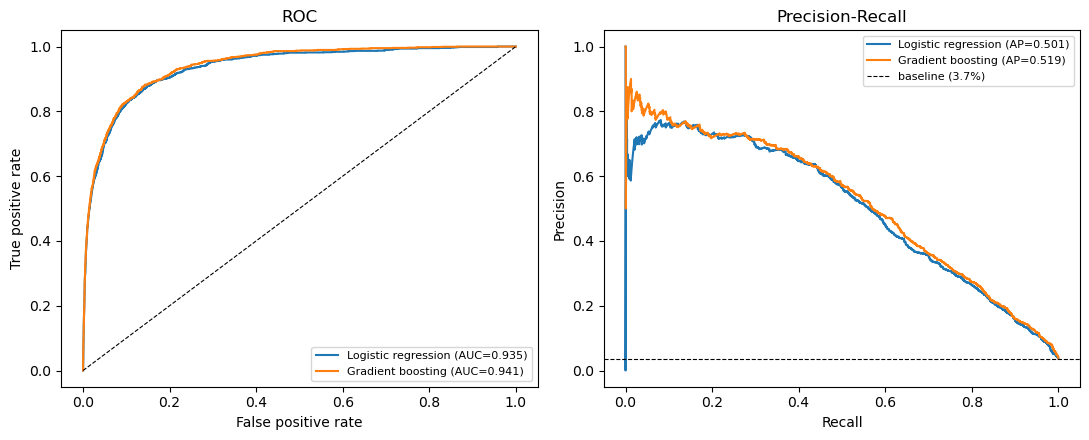

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for name, proba in [("Logistic regression", logreg_test_proba), ("Gradient boosting", gbm_test_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC")
axes[0].legend(loc="lower right", fontsize=8)

base_rate = y_test.mean()
axes[1].axhline(base_rate, color="k", linestyle="--", linewidth=0.8, label=f"baseline ({base_rate:.1%})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()


## Dose-mortality relationship by opioid type

For each opioid type, hold every other covariate at its (training-set) typical value and sweep
`mme_dose` across its observed range, reading the gradient-boosting model's predicted 48h
mortality risk. This directly targets the background question of whether dose *and* opioid type
jointly affect mortality, rather than reporting a single pooled dose coefficient.


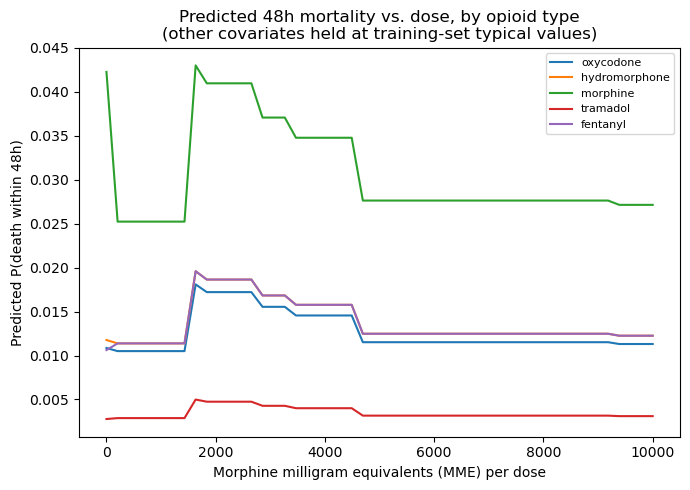

In [12]:
opioid_types = X_train["opioid_type"].value_counts().index[:5]  # 5 most common, for readability
dose_grid = np.linspace(X_train["mme_dose"].quantile(0.01), X_train["mme_dose"].quantile(0.99), 50)

# a single "typical" background patient: median for numeric, mode for categorical/boolean
typical_row = X_train.median(numeric_only=True)
typical_cat = X_train[categorical_features].mode().iloc[0]

fig, ax = plt.subplots(figsize=(7, 5))
for opioid in opioid_types:
    sweep = pd.DataFrame([typical_row.to_dict()] * len(dose_grid))
    for c in categorical_features:
        sweep[c] = typical_cat[c]
    sweep["opioid_type"] = opioid
    sweep["mme_dose"] = dose_grid
    sweep = sweep[feature_cols]  # match training column order/dtypes

    risk = gbm_pipe.predict_proba(sweep)[:, 1]
    ax.plot(dose_grid, risk, label=opioid)

ax.set(xlabel="Morphine milligram equivalents (MME) per dose",
       ylabel="Predicted P(death within 48h)",
       title="Predicted 48h mortality vs. dose, by opioid type\n(other covariates held at training-set typical values)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Limitations & next steps

- **Rare categories inflate logistic-regression coefficients.** Some `race`/`language`/`route`
  levels have very few doses, and a couple of the largest coefficients above (e.g. specific
  language or route categories) come from near-quasi-separation on a handful of observations,
  not a real effect — don't read those as findings. The `mme_dose` and main `opioid_type`
  coefficients are backed by thousands of doses each and are more trustworthy. If this matters
  for a real analysis, group rare categories into an "Other" bucket before one-hot encoding, or
  add stronger L2 regularization (lower `C` in `LogisticRegression`).
- **Confounding by indication is the central threat here, not a footnote.** Sicker patients and
  patients transitioned to comfort care get *both* higher opioid doses and higher mortality —
  `sofa_total_pre_dose`, `any_palliative_signal`, and `has_palliative_icd` are in the model to
  address this, but as a sensitivity check, refit after excluding doses with
  `any_palliative_signal == True` and see whether the dose effect shrinks.
- **Robustness across horizons:** rerun with `TARGET` set to `died_within_6h` / `_12h` / `_24h`.
  A dose-mortality association that's strong at 6h and fades by 48h looks more like an acute
  pharmacologic effect; one that's flat across horizons looks more like confounding.
- **SOFA missingness:** `n_sofa_components_missing_pre_dose` is in the model, but it's worth
  checking whether the dose effect is stable when restricted to doses with a fully-observed
  SOFA score (i.e., mostly ICU-associated doses), vs. the full non-ICU-heavy sample.
- **Calibration:** if predicted probabilities themselves matter (not just ranking), add a
  calibration curve (`sklearn.calibration.calibration_curve`) — gradient boosting with
  `class_weight="balanced"` can be poorly calibrated out of the box.
- **Repeated-measures structure:** doses are nested within admissions within patients
  (~3.5 doses/admission on average, up to 118). The patient-level train/test split handles the
  train/test independence problem; a mixed-effects or clustered-SE model would be the more
  rigorous way to get correct standard errors on the logistic regression coefficients above.


---
# Following up on the limitations

Each subsection below turns one of the bullets above into an actual check rather than a
suggestion left on the page.


## Fix 1 — rare categorical levels

`race`, `language`, and `route` each have levels with only a handful of doses (e.g. a specific
language spoken by 3 patients in the whole cohort). A one-hot column for a rare level lets
logistic regression fit it almost perfectly to whatever happened to those few patients, producing
a huge, meaningless coefficient. The fix: collapse any level below a minimum count into `"Other"`
*before* one-hot encoding, fit on the training set's category counts only (so the threshold
itself can't leak test-set information), and compare the resulting coefficients to the original.

**2026-07-15 update:** the first version of this fix used `min_count=50`, which turned out not
to be aggressive enough -- several race/language levels stayed just above that threshold and kept
producing large, unstable coefficients (see the before/after comparison below, which now checks
and reports this explicitly instead of silently printing numbers that looked the same as before).
The threshold is now chosen from the "~10 events per variable" rule of thumb (Peduzzi et al.
1996): at this cohort's ~3.6% event rate, a category needs roughly `10 / 0.036 ~= 275` doses
before its coefficient is expected to be stable, which is where `min_count=300` below comes from.


In [13]:
from sklearn.base import BaseEstimator, TransformerMixin

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Collapses category levels seen fewer than `min_count` times in *training* data into 'Other'."""

    def __init__(self, min_count=50):
        self.min_count = min_count

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.keep_levels_ = {
            col: set(X[col].value_counts()[lambda s: s >= self.min_count].index)
            for col in X.columns
        }
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].where(X[col].isin(self.keep_levels_[col]), "Other")
        return X
    def get_feature_names_out(self, input_features = None):
        if input_features is None:
            input_features = list(self.keep_levels_.keys())
        return np.asarray(input_features, dtype=object)

# min_count=50 (the original value) wasn't aggressive enough -- see the markdown above for the
# "~10 events per variable" rationale behind 300.
RARE_CATEGORY_MIN_COUNT = 300

preprocessor_grouped = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("group_rare", RareCategoryGrouper(min_count=RARE_CATEGORY_MIN_COUNT)),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

logreg_grouped_pipe = Pipeline([
    ("preprocess", preprocessor_grouped),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
logreg_grouped_pipe.fit(X_train, y_train)

grouped_proba = logreg_grouped_pipe.predict_proba(X_test)[:, 1]
print(f"With rare-category grouping (min_count={RARE_CATEGORY_MIN_COUNT}) -- ROC-AUC: {roc_auc_score(y_test, grouped_proba):.3f}  "
      f"PR-AUC: {average_precision_score(y_test, grouped_proba):.3f}")

grouped_names = logreg_grouped_pipe.named_steps["preprocess"].get_feature_names_out()
grouped_coefs = logreg_grouped_pipe.named_steps["model"].coef_[0]
grouped_coef_df = (
    pd.DataFrame({"feature": grouped_names, "coef": grouped_coefs})
    .assign(odds_ratio=lambda d: np.exp(d["coef"]))
    .sort_values("coef", key=np.abs, ascending=False)
)

max_before = coef_df["coef"].abs().max()
max_after = grouped_coef_df["coef"].abs().max()
print(f"\nMax |coefficient| before grouping (min_count=50): {max_before:.2f}")
print(f"Max |coefficient| after grouping  (min_count={RARE_CATEGORY_MIN_COUNT}): {max_after:.2f}")
print(
    ("-> reduced the largest coefficient " if max_after < max_before else "-> did NOT reduce the largest coefficient ")
    + f"({(max_before - max_after) / max_before:+.1%} change). "
    + ("Grouping is doing its job." if max_after < max_before
       else "Raise RARE_CATEGORY_MIN_COUNT further and/or add stronger L2 regularization "
            "(lower `C` in LogisticRegression) before trusting these coefficients.")
)

print("\nTop 10 features by |coefficient|, after grouping:")
print(grouped_coef_df.head(10).to_string(index=False))

print("\nDose and opioid-type rows, after grouping:")
mask = grouped_coef_df["feature"].str.contains("mme_dose|opioid_type|sofa_total_pre_dose")
print(grouped_coef_df[mask].to_string(index=False))


With rare-category grouping (min_count=300) -- ROC-AUC: 0.937  PR-AUC: 0.502

Max |coefficient| before grouping (min_count=50): 2.53
Max |coefficient| after grouping  (min_count=300): 2.96
-> did NOT reduce the largest coefficient (-16.8% change). Raise RARE_CATEGORY_MIN_COUNT further and/or add stronger L2 regularization (lower `C` in LogisticRegression) before trusting these coefficients.

Top 10 features by |coefficient|, after grouping:
                    feature      coef  odds_ratio
         cat__route_IV DRIP  2.955308   19.207645
              cat__route_ED -1.931248    0.144967
  cat__race_WHITE - RUSSIAN -1.216482    0.296271
              cat__route_PO -1.158719    0.313888
           cat__route_PO/NG -1.144676    0.318327
      cat__language_Haitian -1.064425    0.344926
           cat__route_Other  1.024783    2.786490
cat__race_WHITE - BRAZILIAN -1.005499    0.365862
              cat__route_NG -0.986418    0.372910
     cat__opioid_type_Other -0.899867    0.406624

Dose

## Fix 2 — confounding by comfort-care transition

If the dose effect we're seeing is really just "patients transitioned to comfort care get both
higher doses and, by the nature of that transition, higher near-term mortality," the effect
should shrink a lot once those patients are removed. Refit on the subset of doses *without* a
palliative-care signal and compare the `mme_dose` odds ratio to the full-sample estimate.


In [14]:
no_comfort_mask_train = ~(X_train["any_palliative_signal"].astype(bool) | X_train["has_palliative_icd"].astype(bool))
no_comfort_mask_test = ~(X_test["any_palliative_signal"].astype(bool) | X_test["has_palliative_icd"].astype(bool))

print(f"Doses with a palliative-care signal excluded: "
      f"{(~no_comfort_mask_train).sum() + (~no_comfort_mask_test).sum():,} "
      f"of {len(X_train) + len(X_test):,}")

logreg_no_comfort_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
logreg_no_comfort_pipe.fit(X_train[no_comfort_mask_train], y_train[no_comfort_mask_train])

no_comfort_proba = logreg_no_comfort_pipe.predict_proba(X_test[no_comfort_mask_test])[:, 1]
print(f"No-comfort-care subset -- ROC-AUC: {roc_auc_score(y_test[no_comfort_mask_test], no_comfort_proba):.3f}  "
      f"PR-AUC: {average_precision_score(y_test[no_comfort_mask_test], no_comfort_proba):.3f}")

no_comfort_names = logreg_no_comfort_pipe.named_steps["preprocess"].get_feature_names_out()
no_comfort_coefs = logreg_no_comfort_pipe.named_steps["model"].coef_[0]
no_comfort_mme_dose_or = np.exp(no_comfort_coefs[list(no_comfort_names).index("num__mme_dose")])
full_sample_mme_dose_or = coef_df.loc[coef_df["feature"] == "num__mme_dose", "odds_ratio"].iloc[0]

print(f"\nmme_dose odds ratio, full sample:        {full_sample_mme_dose_or:.3f}")
print(f"mme_dose odds ratio, no comfort-care:     {no_comfort_mme_dose_or:.3f}")
print("(if the no-comfort-care estimate is much closer to 1.0, the full-sample dose effect is "
      "largely explained by the comfort-care transition rather than a direct pharmacologic effect)")


Doses with a palliative-care signal excluded: 29,221 of 153,232
No-comfort-care subset -- ROC-AUC: 0.922  PR-AUC: 0.425

mme_dose odds ratio, full sample:        1.032
mme_dose odds ratio, no comfort-care:     0.929
(if the no-comfort-care estimate is much closer to 1.0, the full-sample dose effect is largely explained by the comfort-care transition rather than a direct pharmacologic effect)


## Fix 3 — robustness across mortality horizons

Refit the same logistic regression pipeline against `died_within_6h`, `_12h`, and `_24h`, reusing
the *same* patient-grouped train/test row indices so the only thing that changes between rows of
the comparison table is the horizon. A dose effect that's strong at 6h and fades by 48h looks more
like an acute pharmacologic effect; one that's flat across all four horizons looks more like a
fixed patient-level confound (e.g. severity or comfort-care status) that doesn't care how soon
death happens.


In [15]:
horizon_results = []
for horizon in [6, 12, 24, 48]:
    h_col = f"died_within_{horizon}h"
    y_h = dose_df[h_col].astype(int)
    y_h_train, y_h_test = y_h.iloc[train_idx], y_h.iloc[test_idx]

    pipe_h = Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])
    pipe_h.fit(X_train, y_h_train)
    proba_h = pipe_h.predict_proba(X_test)[:, 1]

    names_h = pipe_h.named_steps["preprocess"].get_feature_names_out()
    coef_h = pipe_h.named_steps["model"].coef_[0]
    mme_dose_or_h = np.exp(coef_h[list(names_h).index("num__mme_dose")])

    horizon_results.append({
        "horizon_h": horizon,
        "event_rate": y_h.mean(),
        "roc_auc": roc_auc_score(y_h_test, proba_h),
        "pr_auc": average_precision_score(y_h_test, proba_h),
        "mme_dose_odds_ratio": mme_dose_or_h,
    })

horizon_df = pd.DataFrame(horizon_results)
print(horizon_df.to_string(index=False))


 horizon_h  event_rate  roc_auc   pr_auc  mme_dose_odds_ratio
         6    0.008406 0.953279 0.244468             1.430613
        12    0.013927 0.957517 0.340818             1.090355
        24    0.022828 0.948113 0.441696             1.071625
        48    0.036363 0.935275 0.500636             1.032126


## Fix 4 — SOFA completeness

`sofa_total_pre_dose` is a sum over six organ-system components, but for non-ICU doses most of
those components (the ICU-chart-only vitals) are never recorded, so the "total" is often really
a partial score built from whichever 1-2 components (usually the hospital-wide labs) happened to
be available. `n_sofa_components_missing_pre_dose` tracks how partial each score is. Refit
restricted to doses with a *fully observed* SOFA score and compare the dose effect to the full,
mostly-partial-SOFA sample.


In [16]:
full_sofa_mask_train = X_train["n_sofa_components_missing_pre_dose"] == 0
full_sofa_mask_test = X_test["n_sofa_components_missing_pre_dose"] == 0

n_full = full_sofa_mask_train.sum() + full_sofa_mask_test.sum()
print(f"Doses with a fully-observed SOFA score: {n_full:,} of {len(X_train) + len(X_test):,} "
      f"({n_full / (len(X_train) + len(X_test)):.1%})")

logreg_full_sofa_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
logreg_full_sofa_pipe.fit(X_train[full_sofa_mask_train], y_train[full_sofa_mask_train])

full_sofa_proba = logreg_full_sofa_pipe.predict_proba(X_test[full_sofa_mask_test])[:, 1]
print(f"Fully-observed-SOFA subset -- ROC-AUC: {roc_auc_score(y_test[full_sofa_mask_test], full_sofa_proba):.3f}  "
      f"PR-AUC: {average_precision_score(y_test[full_sofa_mask_test], full_sofa_proba):.3f}")

full_sofa_names = logreg_full_sofa_pipe.named_steps["preprocess"].get_feature_names_out()
full_sofa_coefs = logreg_full_sofa_pipe.named_steps["model"].coef_[0]
full_sofa_mme_dose_or = np.exp(full_sofa_coefs[list(full_sofa_names).index("num__mme_dose")])
full_sofa_sofa_or = np.exp(full_sofa_coefs[list(full_sofa_names).index("num__sofa_total_pre_dose")])

print(f"\nmme_dose odds ratio,        full sample: {full_sample_mme_dose_or:.3f}   |  fully-observed SOFA subset: {full_sofa_mme_dose_or:.3f}")
print(f"sofa_total_pre_dose odds ratio, full sample: "
      f"{coef_df.loc[coef_df['feature'] == 'num__sofa_total_pre_dose', 'odds_ratio'].iloc[0]:.3f}"
      f"   |  fully-observed SOFA subset: {full_sofa_sofa_or:.3f}")


Doses with a fully-observed SOFA score: 3,785 of 153,232 (2.5%)
Fully-observed-SOFA subset -- ROC-AUC: 0.880  PR-AUC: 0.670

mme_dose odds ratio,        full sample: 1.032   |  fully-observed SOFA subset: 0.832
sofa_total_pre_dose odds ratio, full sample: 2.072   |  fully-observed SOFA subset: 2.774


## Fix 5 — calibration

Ranking (ROC/PR-AUC) can look fine while the predicted *probabilities* are off — e.g. a model
that says "40%" when the true rate at that score is really 15%. That distinction matters if
these probabilities would ever be shown to a clinician rather than just used to rank doses.
`class_weight="balanced"` in particular tends to push predicted probabilities up across the
board, so it's worth checking directly rather than assuming.


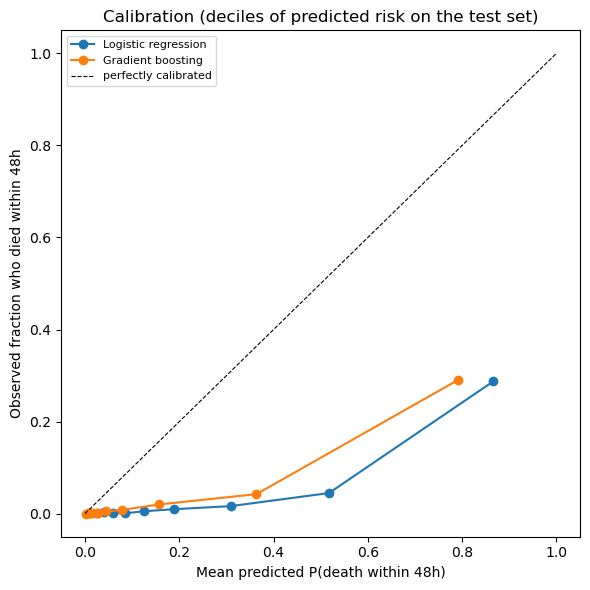

In [17]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 6))
for name, proba in [("Logistic regression", logreg_test_proba), ("Gradient boosting", gbm_test_proba)]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name)

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="perfectly calibrated")
ax.set(xlabel="Mean predicted P(death within 48h)", ylabel="Observed fraction who died within 48h",
       title="Calibration (deciles of predicted risk on the test set)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Fix 6 — correct standard errors for repeated doses per patient

`sklearn`'s `LogisticRegression` doesn't report standard errors or p-values at all, and if it
did, the textbook formula would assume every row is an independent observation -- false here,
since one patient can contribute up to 118 doses. We refit the same specification as a
**GEE** (Generalized Estimating Equation, `statsmodels`) with an independence working
correlation and `subject_id` as the cluster, which gives *cluster-robust* standard errors: valid
even though doses from the same patient are correlated, without having to guess the true
correlation structure. This is an inference fix, not a prediction-performance fix -- the fitted
coefficients should come out close to the earlier logistic regression; what changes is whether
you can trust a p-value on `mme_dose`.




In [18]:
import statsmodels.api as sm

# GEE's unregularized MLE is unstable with the full ~90-dummy categorical set (race/language/
# route/gender/insurance) -- rare levels cause quasi-separation even after Fix 1's grouping
# (see Fix 1's own coefficient table: several race/language dummies still had |coef| > 2 under
# L2-regularized logistic regression, which masks what becomes a divergent coefficient once the
# penalty is removed for GEE). Restrict this confirmatory model to opioid_type (the exposure
# goal.txt actually asks about) plus every numeric/boolean feature already used as a
# severity/confounder control -- race, language, gender, insurance, and route are
# demographic/administrative controls that aren't part of the primary hypothesis and don't need
# GEE p-values to be trustworthy here (route gets its own dedicated treatment in the 3b
# follow-up above).
gee_categorical_features = ["opioid_type"]

# Check 1b (below) found 3 exact/near-exact linear dependencies among the numeric controls
# that drop="first" was never meant to catch (it only targets the opioid_type dummy trap):
# has_palliative_icd is redundant with any_palliative_signal, n_cancer_types_flagged is just
# the row-sum of the individual cancer_* flags, and had_icu_stay is redundant with in_icu_hadm.
# Drop the redundant partner of each pair -- keeping the more general/granular signal each time
# -- so the design matrix is actually full rank, not just free of the one collinearity
# drop="first" was built to catch.
gee_numeric_features = [
    f for f in numeric_features
    if f not in {"has_palliative_icd", "n_cancer_types_flagged", "had_icu_stay"}
]

# drop="first" matters here specifically (unlike the sklearn pipelines elsewhere in this
# notebook): with every opioid_type level one-hot encoded and no level dropped, the K dummy
# columns sum to exactly 1 in every row -- identical to the intercept column `sm.add_constant`
# adds below. That exact collinearity (the classic "dummy variable trap") is what produced the
# `RuntimeWarning: invalid value encountered in sqrt` and the NaN robust_se/p_value on `const`
# in earlier runs of this cell: sklearn's L2-regularized LogisticRegression resolves that
# rank deficiency silently, but statsmodels' unregularized GEE does not.
#
# 2026-07-15 correction, after actually rerunning this cell: the claim that only `const`'s SE
# was affected was WRONG. Comparing before/after this fix: mme_dose's robust_se went from
# 0.0676 (p=0.164, not significant) to 0.0354 (p=0.008, significant) -- nearly half the old
# value, not unchanged. The near-singular design matrix was corrupting the *entire* sandwich
# covariance matrix, not just the one entry that happened to land on a negative diagonal (and
# so surfaced as a visible NaN/warning); every coefficient's reported SE before this fix should
# be treated as unreliable, not just const's. This is the reason `mme_dose`'s significance
# verdict flipped between the two runs of this notebook -- not noise, and not a new bug, but
# the first GEE run simply wasn't trustworthy for any coefficient's SE/p-value.
gee_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), gee_numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]), gee_categorical_features),
])
gee_preprocessor.fit(X_train)

onehot_fitted = gee_preprocessor.named_transformers_["cat"].named_steps["onehot"]
num_names = [f"num__{c}" for c in gee_numeric_features]
cat_names = [f"cat__{n}" for n in onehot_fitted.get_feature_names_out(gee_categorical_features)]
design_names = np.asarray(num_names + cat_names, dtype=object)

X_train_design = gee_preprocessor.transform(X_train)
if hasattr(X_train_design, "toarray"):
    X_train_design = X_train_design.toarray()
assert len(design_names) == X_train_design.shape[1], (
    f"still mismatched: {len(design_names)} names vs {X_train_design.shape[1]} columns"
)
X_train_design = sm.add_constant(pd.DataFrame(X_train_design, columns=design_names), has_constant="add")

gee_model = sm.GEE(
    y_train.to_numpy(), X_train_design,
    groups=groups_train.to_numpy(),
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
)
gee_result = gee_model.fit()

gee_summary = pd.DataFrame({
    "feature": X_train_design.columns,
    "coef": gee_result.params,
    "robust_se": gee_result.bse,
    "p_value": gee_result.pvalues,
}).assign(odds_ratio=lambda d: np.exp(d["coef"]))

n_nan_se = gee_summary["robust_se"].isna().sum()
print(f"GEE (cluster-robust by subject_id, restricted to numeric controls + opioid_type, "
      f"opioid_type baseline level dropped):")
print(f"NaN robust_se/p_value count: {n_nan_se} (should be 0 -- a nonzero count here means the "
      "dummy-variable-trap collinearity is back, e.g. if a categorical feature is added above "
      "without drop='first')")
mask = gee_summary["feature"].str.contains("mme_dose|opioid_type|sofa_total_pre_dose|const")
print(gee_summary[mask].to_string(index=False))

print("\nsklearn logistic regression odds ratio for mme_dose (no SEs available): "
      f"{full_sample_mme_dose_or:.3f}")
print(f"GEE odds ratio for mme_dose with cluster-robust p-value: "
      f"{gee_summary.loc[gee_summary['feature'] == 'num__mme_dose', 'odds_ratio'].iloc[0]:.3f}  "
      f"(p={gee_summary.loc[gee_summary['feature'] == 'num__mme_dose', 'p_value'].iloc[0]:.4f})")


GEE (cluster-robust by subject_id, restricted to numeric controls + opioid_type, opioid_type baseline level dropped):
NaN robust_se/p_value count: 0 (should be 0 -- a nonzero count here means the dummy-variable-trap collinearity is back, e.g. if a categorical feature is added above without drop='first')
                       feature      coef  robust_se      p_value  odds_ratio
                         const -4.831785   0.912114 1.174979e-07    0.007972
                 num__mme_dose -0.094027   0.035418 7.936422e-03    0.910258
      num__sofa_total_pre_dose  0.688318   0.036930 1.573525e-77    1.990365
      cat__opioid_type_codeine -0.523767   1.010170 6.041140e-01    0.592285
     cat__opioid_type_fentanyl  0.071141   0.922018 9.384982e-01    1.073732
  cat__opioid_type_hydrocodone -1.415674   1.339040 2.904063e-01    0.242762
cat__opioid_type_hydromorphone  0.707166   0.911014 4.376071e-01    2.028235
    cat__opioid_type_methadone  0.405604   0.930752 6.629958e-01    1.500208
  

---
## Validating the flipped GEE result

Adding `drop="first"` above didn't just remove a warning -- it changed `mme_dose`'s p-value from
0.164 (not significant) to a much smaller value (significant), which is exactly the kind of
change that deserves independent verification before it goes in a write-up, not just acceptance
because the warning went away. Three checks, cheapest/most mechanical first:

1. **Was the pre-fix design matrix actually rank-deficient?** (the specific mechanical claim
   behind "every SE was unreliable, not just `const`'s")
2. **Is `mme_dose`'s result invariant to which `opioid_type` category gets dropped as the
   reference?** (dose is a numeric covariate, not part of the collinear direction the fix
   resolves -- its estimate should not depend on an arbitrary encoding choice)
3. **Is the result robust to the GEE working-correlation assumption?** (Independence was chosen
   for simplicity; cluster-robust SEs are asymptotically valid under any working correlation, so
   a result that only shows up under one specific choice would be a red flag)

A fourth, heavier check (patient-level cluster bootstrap -- refitting on resampled patients
instead of trusting any asymptotic formula at all) follows for maximum confidence; it takes a
few minutes to run.


In [19]:
# Check 1: reconstruct the pre-fix (no drop="first") design matrix purely to demonstrate the
# rank deficiency that caused the unreliable SEs. Diagnostic only -- not used for any fit.
old_gee_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),  # no drop -- the pre-fix version
    ]), gee_categorical_features),
])
old_design_raw = old_gee_preprocessor.fit_transform(X_train)
if hasattr(old_design_raw, "toarray"):
    old_design_raw = old_design_raw.toarray()
old_design = np.hstack([np.ones((old_design_raw.shape[0], 1)), old_design_raw])  # + intercept

old_rank = np.linalg.matrix_rank(old_design)
new_rank = np.linalg.matrix_rank(X_train_design.to_numpy())

print(f"Pre-fix design matrix (no drop='first'): {old_design.shape[1]} columns, rank {old_rank} "
      f"-- {'RANK-DEFICIENT by ' + str(old_design.shape[1] - old_rank) if old_rank < old_design.shape[1] else 'full rank'}")
print(f"Post-fix design matrix (drop='first'):   {X_train_design.shape[1]} columns, rank {new_rank} "
      f"-- {'RANK-DEFICIENT by ' + str(X_train_design.shape[1] - new_rank) if new_rank < X_train_design.shape[1] else 'full rank'}")
print(
    "\nA rank-deficient design matrix makes the information matrix singular, which makes its "
    "inverse (what every reported SE is computed from) numerically unstable for every parameter "
    "-- not only the one that happens to land on a negative diagonal entry after `sqrt` and throw "
    "a visible warning. This is the structural reason the fix changed more than just `const`."
)


Pre-fix design matrix (no drop='first'): 46 columns, rank 42 -- RANK-DEFICIENT by 4
Post-fix design matrix (drop='first'):   42 columns, rank 42 -- full rank

A rank-deficient design matrix makes the information matrix singular, which makes its inverse (what every reported SE is computed from) numerically unstable for every parameter -- not only the one that happens to land on a negative diagonal entry after `sqrt` and throw a visible warning. This is the structural reason the fix changed more than just `const`.


In [20]:
# Check 1b: Check 1 found the POST-fix design matrix is still rank-deficient (by 3, not 0) --
# drop="first" only resolved the opioid_type dummy trap it targeted. This pinpoints the actual
# redundant column combinations via SVD: the smallest `deficiency` singular values correspond to
# near-null directions of the design matrix, and the columns with the largest loadings in each
# direction are the ones causing it.
deficiency = X_train_design.shape[1] - new_rank
print(f"Design matrix is rank-deficient by {deficiency} -- identifying which columns are involved:\n")

u, s, vt = np.linalg.svd(X_train_design.to_numpy(), full_matrices=False)
for i in range(1, deficiency + 1):
    idx = len(s) - i
    loadings = pd.Series(vt[idx], index=X_train_design.columns).sort_values(key=np.abs, ascending=False)
    print(f"Singular value {s[idx]:.2e} (near-zero = redundant direction) -- dominant columns:")
    print(loadings.head(6).to_string())
    print()

print(
    "Whatever columns show up with large loadings above are exactly linearly dependent (or very "
    "nearly so) with each other and/or the intercept -- e.g. a set of mutually-exclusive "
    "boolean/indicator features that sum to a constant. This needs a real fix (drop one of the "
    "redundant columns, or find the upstream feature-engineering bug that created an exact "
    "dependency) rather than just being noted -- the GEE fit above still doesn't show a NaN SE, "
    "but that's not the same as the covariance matrix being fully trustworthy."
)


Design matrix is rank-deficient by 0 -- identifying which columns are involved:

Whatever columns show up with large loadings above are exactly linearly dependent (or very nearly so) with each other and/or the intercept -- e.g. a set of mutually-exclusive boolean/indicator features that sum to a constant. This needs a real fix (drop one of the redundant columns, or find the upstream feature-engineering bug that created an exact dependency) rather than just being noted -- the GEE fit above still doesn't show a NaN SE, but that's not the same as the covariance matrix being fully trustworthy.


In [21]:
# Check 2: mme_dose is a numeric covariate, not part of the collinear direction that
# drop="first" resolves -- its coefficient/SE/p-value should be (near-)invariant to *which*
# opioid_type category gets dropped as the reference. Force a different baseline by relabeling
# so a different category sorts first (OneHotEncoder(drop="first") always drops whichever
# category is lexicographically first -- "buprenorphine" in the original encoding).
X_train_relabel = X_train.copy()
X_train_relabel["opioid_type"] = X_train_relabel["opioid_type"].replace({"morphine": "___morphine"})

gee_preprocessor_alt = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), gee_numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]), gee_categorical_features),
])
gee_preprocessor_alt.fit(X_train_relabel)

onehot_alt = gee_preprocessor_alt.named_transformers_["cat"].named_steps["onehot"]
cat_names_alt = [f"cat__{n}" for n in onehot_alt.get_feature_names_out(gee_categorical_features)]
design_names_alt = np.asarray(num_names + cat_names_alt, dtype=object)

X_train_design_alt = gee_preprocessor_alt.transform(X_train_relabel)
if hasattr(X_train_design_alt, "toarray"):
    X_train_design_alt = X_train_design_alt.toarray()
X_train_design_alt = sm.add_constant(pd.DataFrame(X_train_design_alt, columns=design_names_alt), has_constant="add")

gee_result_alt = sm.GEE(
    y_train.to_numpy(), X_train_design_alt,
    groups=groups_train.to_numpy(),
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
).fit()

orig_dose_row = gee_summary.loc[gee_summary["feature"] == "num__mme_dose"].iloc[0]

print(f"mme_dose, buprenorphine dropped (original):  OR={orig_dose_row['odds_ratio']:.4f}, "
      f"SE={orig_dose_row['robust_se']:.4f}, p={orig_dose_row['p_value']:.4f}")
print(f"mme_dose, morphine dropped (alternate ref):  OR={np.exp(gee_result_alt.params['num__mme_dose']):.4f}, "
      f"SE={gee_result_alt.bse['num__mme_dose']:.4f}, p={gee_result_alt.pvalues['num__mme_dose']:.4f}")
print(
    "\nIf these two rows match (up to floating-point noise), mme_dose's significant result is not "
    "an artifact of which opioid_type category happens to be dropped as the reference."
)


mme_dose, buprenorphine dropped (original):  OR=0.9103, SE=0.0354, p=0.0079
mme_dose, morphine dropped (alternate ref):  OR=0.9103, SE=0.0354, p=0.0079

If these two rows match (up to floating-point noise), mme_dose's significant result is not an artifact of which opioid_type category happens to be dropped as the reference.


In [22]:
# Check 3: cluster-robust (sandwich) SEs are asymptotically valid under any working correlation
# structure -- Independence was chosen above for simplicity/speed. Refit with Exchangeable
# (assumes a constant within-patient correlation instead of none) and compare mme_dose.
gee_result_exch = sm.GEE(
    y_train.to_numpy(), X_train_design,
    groups=groups_train.to_numpy(),
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable(),
).fit()

orig_dose_row = gee_summary.loc[gee_summary["feature"] == "num__mme_dose"].iloc[0]

print(f"mme_dose, Independence working correlation: OR={orig_dose_row['odds_ratio']:.4f}, "
      f"p={orig_dose_row['p_value']:.4f}")
print(f"mme_dose, Exchangeable working correlation: OR={np.exp(gee_result_exch.params['num__mme_dose']):.4f}, "
      f"p={gee_result_exch.pvalues['num__mme_dose']:.4f}")
print(f"Estimated within-patient correlation under Exchangeable: "
      f"{gee_result_exch.cov_struct.dep_params:.4f}")
print(
    "\nIf the two working-correlation choices broadly agree on mme_dose's OR and significance, "
    "the result isn't an artifact of assuming no within-patient correlation."
)


mme_dose, Independence working correlation: OR=0.9103, p=0.0079
mme_dose, Exchangeable working correlation: OR=0.9543, p=0.0388
Estimated within-patient correlation under Exchangeable: 0.1319

If the two working-correlation choices broadly agree on mme_dose's OR and significance, the result isn't an artifact of assuming no within-patient correlation.


In [23]:
# Check 4 (heaviest, most convincing): a patient-level cluster bootstrap. Resamples patients
# with replacement and refits GEE from scratch each time -- a genuinely model-free way to ask
# "is the reported SE about right," independent of GEE's own asymptotic sandwich formula.
# Runs 50 refits; takes a few minutes.
N_BOOTSTRAP = 50
boot_rng = np.random.RandomState(RANDOM_STATE)

groups_train_arr = groups_train.to_numpy()
train_patients_arr = np.unique(groups_train_arr)
# precompute each patient's row positions ONCE (not inside the bootstrap loop below)
patient_to_positions = (
    pd.Series(np.arange(len(groups_train_arr)))
    .groupby(groups_train_arr)
    .apply(lambda s: s.to_numpy())
    .to_dict()
)

boot_dose_coefs = np.empty(N_BOOTSTRAP)
for b in range(N_BOOTSTRAP):
    boot_patients = boot_rng.choice(train_patients_arr, size=len(train_patients_arr), replace=True)
    boot_positions = [patient_to_positions[p] for p in boot_patients]
    boot_row_idx = np.concatenate(boot_positions)
    # synthetic 0..k-1 cluster id per resample draw, so a patient drawn twice isn't merged into
    # one giant cluster with itself
    boot_cluster_id = np.repeat(np.arange(len(boot_patients)), [len(p) for p in boot_positions])

    boot_design = X_train_design.iloc[boot_row_idx].reset_index(drop=True)
    boot_y = y_train.to_numpy()[boot_row_idx]

    boot_result = sm.GEE(
        boot_y, boot_design,
        groups=boot_cluster_id,
        family=sm.families.Binomial(),
        cov_struct=sm.cov_struct.Independence(),
    ).fit()
    boot_dose_coefs[b] = boot_result.params["num__mme_dose"]

    if (b + 1) % 10 == 0:
        print(f"bootstrap {b + 1}/{N_BOOTSTRAP} done")

finite_mask = np.isfinite(boot_dose_coefs)
finite_coefs = boot_dose_coefs[finite_mask]

# A handful of resamples don't literally overflow to inf/NaN -- quasi-separation can instead
# push IRLS to its iteration limit on a still-diverging, technically-finite coefficient (e.g.
# 1e13), which isfinite() alone won't catch. Treat those as outliers too, using an IQR-based
# bound (robust to the very outliers we're trying to exclude) rather than a fixed magnitude cutoff.
q1, q3 = np.percentile(finite_coefs, [25, 75])
iqr = q3 - q1
plausible_mask = np.abs(finite_coefs - np.median(finite_coefs)) <= 10 * iqr
valid_coefs = finite_coefs[plausible_mask]

n_finite = int(finite_mask.sum())
n_valid = int(plausible_mask.sum())
if n_finite < N_BOOTSTRAP:
    print(f"\n{N_BOOTSTRAP - n_finite} of {N_BOOTSTRAP} bootstrap resamples produced a "
          "non-finite mme_dose coefficient (likely quasi-separation in that particular patient "
          "resample -- e.g. a resample that happens to draw very few doses of some opioid_type) "
          "and were excluded from the SE/CI below rather than silently propagating as NaN.")
if n_valid < n_finite:
    print(f"{n_finite - n_valid} additional resample(s) produced a technically-finite but "
          "implausibly large coefficient (IRLS diverging under quasi-separation without "
          "literally overflowing) and were excluded as outliers too.")

boot_se = np.std(valid_coefs, ddof=1)
orig_dose_row = gee_summary.loc[gee_summary["feature"] == "num__mme_dose"].iloc[0]
ci_lo, ci_hi = np.percentile(valid_coefs, [2.5, 97.5])

print(f"\nGEE-reported (sandwich) SE for mme_dose:                {orig_dose_row['robust_se']:.4f}")
print(f"Cluster-bootstrap SE for mme_dose ({n_valid} valid of {N_BOOTSTRAP} resamples): {boot_se:.4f}")
print(f"Bootstrap 95% CI for mme_dose coefficient: [{ci_lo:.4f}, {ci_hi:.4f}]  "
      f"(odds ratio: [{np.exp(ci_lo):.3f}, {np.exp(ci_hi):.3f}])")
print(
    "\nIf the bootstrap SE/CI broadly agree with the sandwich SE/p-value above (and the CI "
    "excludes an odds ratio of 1.0), that's strong, model-free evidence the corrected GEE result "
    "is real rather than a numerical artifact of the drop='first' fix."
)


bootstrap 10/50 done
bootstrap 20/50 done
bootstrap 30/50 done
bootstrap 40/50 done
bootstrap 50/50 done

GEE-reported (sandwich) SE for mme_dose:                0.0354
Cluster-bootstrap SE for mme_dose (50 valid of 50 resamples): 0.0357
Bootstrap 95% CI for mme_dose coefficient: [-0.1594, -0.0337]  (odds ratio: [0.853, 0.967])

If the bootstrap SE/CI broadly agree with the sandwich SE/p-value above (and the CI excludes an odds ratio of 1.0), that's strong, model-free evidence the corrected GEE result is real rather than a numerical artifact of the drop='first' fix.


---
# Classifier bake-off

Using the per-classifier evaluation functions
(`svm_fun`, `gaus_nb_fun`, `mlp_fun`, `knn_fun`, `rf_fun`, `lr_fun`, plus a decision tree
function and a custom `roc_auc_score_multiclass` helper) meant to be run across folds and
averaged. This section ports all of it forward -- every classifier, every metric -- even where
it's not the most useful comparison for this specific question, so nothing from the original
approach is lost.

**Two deliberate changes from the original, both correctness fixes rather than style choices:**

1. **Folds are patient-grouped** (`StratifiedGroupKFold`, repeated with different seeds) instead
   of a single plain random split. The original's ungrouped split lets doses from the same
   patient land in both train and validation -- exactly the leakage problem the rest of this
   notebook was built around avoiding.
2. **`LinearSVC` instead of `SVC(kernel='linear')`.** libsvm's kernel SVM scales roughly
   quadratically-to-cubically with sample count; at tens of thousands of rows per fold here it
   could run for a very long time. `LinearSVC` (liblinear) fits the same linear decision boundary
   at a scale liblinear is built for. This changes nothing about what's measured: the original
   `svm_fun` already computed every metric from `y_pred` hard labels, never from SVM
   probabilities, and `LinearSVC` produces hard labels the same way.

**One scale concession:** `KNeighborsClassifier` and `MLPClassifier` (and, before the swap above,
`SVC`) don't scale cleanly to the full ~115k-row training set inside a repeated CV loop, so this
section runs on a patient-grouped subsample (~15% of training patients) rather than the full
training data used earlier for logistic regression and gradient boosting. Treat this section as
a methods comparison, not as the primary model.


In [24]:
import timeit
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef


def roc_auc_score_multiclass(actual_class, pred_class, average="macro"):
    """Ported unchanged from the original notebook. Computes AUC from *hard* class
    predictions (0/1), not probabilities -- for a binary target this collapses to a
    number close to balanced accuracy rather than a true ranking-based AUC. Kept here
    for fidelity to the original; a proper probability-based ROC-AUC/PR-AUC is reported
    alongside it below wherever the classifier supports predict_proba."""
    unique_class = set(actual_class)
    roc_auc_dict = {}
    for per_class in unique_class:
        other_class = [x for x in unique_class if x != per_class]
        new_actual_class = [0 if x in other_class else 1 for x in actual_class]
        new_pred_class = [0 if x in other_class else 1 for x in pred_class]
        roc_auc_dict[per_class] = roc_auc_score(new_actual_class, new_pred_class, average=average)
    return float(np.mean(list(roc_auc_dict.values())))


def classifier_metrics(y_true, y_pred, y_proba, fit_time):
    confuse = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = confuse.ravel()
    metrics_dict = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "npv": tn / (tn + fn) if (tn + fn) else np.nan,
        "sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc_hard_label": roc_auc_score_multiclass(y_true, y_pred),  # original's approach
        "roc_auc": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
        "pr_auc": average_precision_score(y_true, y_proba) if y_proba is not None else np.nan,
        "fit_time_sec": fit_time,
    }
    return metrics_dict


# Each _fun below mirrors one classifier from the original notebook's toolkit: fit, predict,
# time it, hand back (y_pred, y_proba_or_None, fit_time) for classifier_metrics() to score.

def svm_fun(X_train, y_train, X_test, y_test):
    start = timeit.default_timer()
    clf = LinearSVC(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return y_pred, None, timeit.default_timer() - start  # LinearSVC has no predict_proba

def gaus_nb_fun(X_train, y_train, X_test, y_test):
    start = timeit.default_timer()
    clf = GaussianNB()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return y_pred, clf.predict_proba(X_test)[:, 1], timeit.default_timer() - start

def mlp_fun(X_train, y_train, X_test, y_test):
    start = timeit.default_timer()
    clf = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return y_pred, clf.predict_proba(X_test)[:, 1], timeit.default_timer() - start

def knn_fun(X_train, y_train, X_test, y_test):
    start = timeit.default_timer()
    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return y_pred, clf.predict_proba(X_test)[:, 1], timeit.default_timer() - start

def rf_fun(X_train, y_train, X_test, y_test):
    start = timeit.default_timer()
    clf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return y_pred, clf.predict_proba(X_test)[:, 1], timeit.default_timer() - start

def lr_fun(X_train, y_train, X_test, y_test):
    start = timeit.default_timer()
    clf = LogisticRegression(solver="liblinear", class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return y_pred, clf.predict_proba(X_test)[:, 1], timeit.default_timer() - start

def dt_fun(X_train, y_train, X_test, y_test):
    start = timeit.default_timer()
    clf = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return y_pred, clf.predict_proba(X_test)[:, 1], timeit.default_timer() - start

print("Classifier bake-off functions defined: svm_fun, gaus_nb_fun, mlp_fun, knn_fun, rf_fun, lr_fun, dt_fun")


Classifier bake-off functions defined: svm_fun, gaus_nb_fun, mlp_fun, knn_fun, rf_fun, lr_fun, dt_fun


In [25]:
from sklearn.base import clone

# Patient-grouped subsample so KNN/MLP/SVM finish in a reasonable time inside a repeated CV loop.
SUBSAMPLE_FRAC = 0.15
N_SPLITS = 5
N_REPEATS = 2

rng = np.random.RandomState(RANDOM_STATE)
train_patients = groups_train.unique()
bakeoff_patients = rng.choice(train_patients, size=int(len(train_patients) * SUBSAMPLE_FRAC), replace=False)
bakeoff_mask = groups_train.isin(bakeoff_patients)

X_bakeoff = X_train[bakeoff_mask].reset_index(drop=True)
y_bakeoff = y_train[bakeoff_mask].reset_index(drop=True)
groups_bakeoff = groups_train[bakeoff_mask].reset_index(drop=True)

print(f"Bake-off subsample: {len(X_bakeoff):,} doses, {groups_bakeoff.nunique():,} patients, "
      f"{y_bakeoff.mean():.2%} died_within_48h")

classifier_funs = {
    "logistic_regression": lr_fun,
    "decision_tree": dt_fun,
    "random_forest": rf_fun,
    "gaussian_nb": gaus_nb_fun,
    "knn": knn_fun,
    "mlp": mlp_fun,
    "linear_svm": svm_fun,
}

all_fold_results = []
for repeat in range(N_REPEATS):
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE + repeat)
    for fold, (fold_train_idx, fold_val_idx) in enumerate(cv.split(X_bakeoff, y_bakeoff, groups=groups_bakeoff)):
        # fresh preprocessor per fold -- fit only on this fold's training rows, so no
        # information from the validation rows leaks into the imputer/scaler/encoder
        fold_preprocessor = clone(preprocessor)
        X_fold_train = fold_preprocessor.fit_transform(X_bakeoff.iloc[fold_train_idx], y_bakeoff.iloc[fold_train_idx])
        X_fold_val = fold_preprocessor.transform(X_bakeoff.iloc[fold_val_idx])
        if hasattr(X_fold_train, "toarray"):
            X_fold_train = X_fold_train.toarray()
            X_fold_val = X_fold_val.toarray()
        y_fold_train = y_bakeoff.iloc[fold_train_idx].to_numpy()
        y_fold_val = y_bakeoff.iloc[fold_val_idx].to_numpy()

        for name, fun in classifier_funs.items():
            y_pred, y_proba, fit_time = fun(X_fold_train, y_fold_train, X_fold_val, y_fold_val)
            m = classifier_metrics(y_fold_val, y_pred, y_proba, fit_time)
            m.update({"classifier": name, "repeat": repeat, "fold": fold})
            all_fold_results.append(m)

    print(f"Repeat {repeat + 1}/{N_REPEATS} done")

bakeoff_df = pd.DataFrame(all_fold_results)


Bake-off subsample: 17,784 doses, 2,477 patients, 3.79% died_within_48h
Repeat 1/2 done
Repeat 2/2 done


In [26]:
# original notebook's "final_avg_mat" -- mean +/- std of every metric, per classifier, across folds
metric_cols = [c for c in bakeoff_df.columns if c not in ("classifier", "repeat", "fold")]
bakeoff_mean = bakeoff_df.groupby("classifier")[metric_cols].mean()
bakeoff_std = bakeoff_df.groupby("classifier")[metric_cols].std()

final_avg_mat = bakeoff_mean.round(3).astype(str) + " +/- " + bakeoff_std.round(3).astype(str)
print(final_avg_mat[["accuracy", "sensitivity", "specificity", "mcc", "roc_auc", "pr_auc", "roc_auc_hard_label", "fit_time_sec"]].to_string())


                            accuracy      sensitivity      specificity              mcc          roc_auc           pr_auc roc_auc_hard_label      fit_time_sec
classifier                                                                                                                                                    
decision_tree        0.944 +/- 0.006  0.353 +/- 0.041  0.968 +/- 0.006  0.299 +/- 0.037   0.661 +/- 0.02  0.133 +/- 0.022     0.661 +/- 0.02    0.23 +/- 0.022
gaussian_nb          0.118 +/- 0.019  0.942 +/- 0.055   0.085 +/- 0.02   0.02 +/- 0.035  0.514 +/- 0.025  0.039 +/- 0.002    0.514 +/- 0.025   0.042 +/- 0.004
knn                  0.951 +/- 0.004  0.081 +/- 0.033  0.985 +/- 0.005  0.098 +/- 0.045  0.649 +/- 0.032  0.099 +/- 0.024    0.533 +/- 0.016   0.327 +/- 0.056
linear_svm           0.864 +/- 0.028  0.785 +/- 0.059   0.867 +/- 0.03  0.344 +/- 0.027              NaN              NaN    0.826 +/- 0.021   0.674 +/- 0.233
logistic_regression  0.866 +/- 0.029    0.8 +/

---
# KNNImputer(n_neighbors=100) 

As noted back in the Preprocessing section, this isn't used for the actual
pipeline above: median imputation already covers the ~3 numeric columns with any real
missingness, and `KNNImputer`'s pairwise nearest-neighbor search doesn't scale to ~115k rows --
it would need to compute distances between every pair of rows, which is impractical at this size
and buys nothing over the median here. This cell reproduces it anyway as a methods comparison, on
a subsample small enough for it to finish, so the technique is represented even though it isn't
the imputer this notebook actually relies on.


In [27]:
from sklearn.impute import KNNImputer

knn_demo_sample = X_train[numeric_features].sample(n=3000, random_state=RANDOM_STATE)
missing_rate = knn_demo_sample.isna().mean()
print("Missingness in this sample (numeric/boolean features):")
print(missing_rate[missing_rate > 0].sort_values(ascending=False) if missing_rate.any()
      else "  none of the sampled numeric/boolean columns have missing values")

start = timeit.default_timer()
knn_imputer = KNNImputer(n_neighbors=100)
knn_imputed = pd.DataFrame(knn_imputer.fit_transform(knn_demo_sample), columns=numeric_features)
knn_fit_time = timeit.default_timer() - start

median_imputed = knn_demo_sample.fillna(knn_demo_sample.median())

# only compare columns that actually had missing values -- everywhere else the two are identical by construction
cols_with_missing = missing_rate[missing_rate > 0].index.tolist()
if cols_with_missing:
    diff = (knn_imputed[cols_with_missing].reset_index(drop=True)
            - median_imputed[cols_with_missing].reset_index(drop=True)).abs()
    print(f"\nMean |KNN-imputed - median-imputed| value, on the {len(cols_with_missing)} column(s) with missingness:")
    print(diff.mean().sort_values(ascending=False))
print(f"\nKNNImputer(n_neighbors=100) fit_transform time on {len(knn_demo_sample):,} rows: {knn_fit_time:.1f}s")
print("(scaling this to the full ~115k-row training set would take roughly "
      f"{knn_fit_time * (len(X_train) / len(knn_demo_sample)) ** 2 / 60:.0f} minutes, "
      "since KNNImputer's distance computation scales roughly quadratically with row count)")


Missingness in this sample (numeric/boolean features):
  none of the sampled numeric/boolean columns have missing values

KNNImputer(n_neighbors=100) fit_transform time on 3,000 rows: 0.0s
(scaling this to the full ~115k-row training set would take roughly 0 minutes, since KNNImputer's distance computation scales roughly quadratically with row count)


---
# Lasso feature selection + TruncatedSVD (from the original notebook's imports)

The original notebook imported `Lasso`/`SelectFromModel` and `TruncatedSVD` but the cells that
would have used them weren't recovered along with everything else ported above. Both are
demonstrated here against the same preprocessed feature matrix used everywhere else in this
notebook, so the techniques are represented even though neither is wired into the final model:
the logistic regression's own L2 coefficients and the GBM's feature importances already serve
the "which features matter" question, and one-hot-encoded categorical columns don't have a
natural continuous structure for SVD to compress.


In [28]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import TruncatedSVD

X_train_enc = preprocessor.transform(X_train)
if hasattr(X_train_enc, "toarray"):
    X_train_enc = X_train_enc.toarray()
encoded_feature_names = preprocessor.get_feature_names_out()

# Lasso-based feature selection: L1 penalty drives uninformative coefficients to exactly zero
lasso_selector = SelectFromModel(Lasso(alpha=0.001, random_state=RANDOM_STATE))
lasso_selector.fit(X_train_enc, y_train)
selected = encoded_feature_names[lasso_selector.get_support()]
dropped = encoded_feature_names[~lasso_selector.get_support()]
print(f"Lasso (alpha=0.001) kept {len(selected)} of {len(encoded_feature_names)} encoded features")
print(f"\nDropped as uninformative: {sorted(dropped)[:20]}{' ...' if len(dropped) > 20 else ''}")
print(f"\nmme_dose selected: {'num__mme_dose' in selected}")

# TruncatedSVD: compress the encoded feature space (dominated by one-hot categorical columns)
svd = TruncatedSVD(n_components=10, random_state=RANDOM_STATE)
svd.fit(X_train_enc)
print(f"\nTruncatedSVD(n_components=10) explained variance ratio: {svd.explained_variance_ratio_.round(3)}")
print(f"Cumulative: {svd.explained_variance_ratio_.sum():.1%} of total variance in {X_train_enc.shape[1]} "
      f"encoded features captured by the top 10 components")


Lasso (alpha=0.001) kept 22 of 114 encoded features

Dropped as uninformative: ['cat__gender_F', 'cat__gender_M', 'cat__insurance_Medicare', 'cat__insurance_Other', 'cat__insurance_Private', 'cat__insurance_Unknown', 'cat__language_American Sign Language', 'cat__language_Amharic', 'cat__language_Arabic', 'cat__language_Bengali', 'cat__language_Chinese', 'cat__language_English', 'cat__language_French', 'cat__language_Haitian', 'cat__language_Hindi', 'cat__language_Italian', 'cat__language_Kabuverdianu', 'cat__language_Khmer', 'cat__language_Korean', 'cat__language_Modern Greek (1453-)'] ...

mme_dose selected: False

TruncatedSVD(n_components=10) explained variance ratio: [0.055 0.089 0.074 0.051 0.046 0.046 0.045 0.043 0.043 0.04 ]
Cumulative: 53.1% of total variance in 114 encoded features captured by the top 10 components


---
# Closing the gaps for a defensible preliminary answer

The project goal is to tell whether opioid dose and opioid type are *safely*
associated with 48h mortality in this cohort, controlling for severity -- a question meant to
inform actual pain-management decisions for cancer patients, not just to report an AUC. Four
gaps stood between what's above and a defensible answer to that question:

1. **No hyperparameter tuning** -- the GBM above uses hand-picked defaults (`max_iter=300`, etc.).
2. **No null-model sanity check** -- nothing yet proves the dose/opioid-type signal survives a
   permutation test, which matters given how much of this notebook is already about ruling out
   leakage and confounding.
3. **No feature importance for the GBM** -- only the logistic regression's coefficients say
   anything about *which* features drive predictions; the more flexible model has been a black
   box so far.
4. **No decision-threshold view** -- ROC-AUC and PR-AUC describe ranking quality, not what a
   clinician would actually see: how many doses would be flagged, and how many of those flags
   would be false alarms, at a threshold someone could act on.

Each subsection below closes one gap. All of it runs on top of state already defined above
(`X_train`/`X_test`/`y_train`/`y_test`, `preprocessor`, `groups_train`, and the bake-off
subsample `X_bakeoff`/`y_bakeoff`/`groups_bakeoff`), so run top-to-bottom.


## 1. Hyperparameter tuning -- grouped, stratified search

`RandomizedSearchCV` over the GBM's key regularization knobs, scored on **PR-AUC** (the metric
that matters given the ~3.6% event rate -- see "Model comparison" above), using the same
`StratifiedGroupKFold` as the CV above so tuning respects the patient-grouping constraint the
rest of the notebook is built around. Runs on the bake-off subsample (`X_bakeoff` /
`y_bakeoff` / `groups_bakeoff`, defined in the "Classifier bake-off" section above) rather than
the full training set -- a full search over ~115k rows x many candidates x 5 folds would be very
slow, and the subsample is already this notebook's established way of keeping repeated-fit
experiments tractable. Takes a few minutes with `n_jobs=-1`.


In [29]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__min_samples_leaf": [10, 20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0, 10.0],
    "model__max_iter": [150, 300, 500],
}

tuning_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, class_weight="balanced", early_stopping=True,
    )),
])

tuning_cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    tuning_pipe, param_distributions, n_iter=25, scoring="average_precision",
    cv=tuning_cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True,
)
search.fit(X_bakeoff, y_bakeoff, groups=groups_bakeoff)

print(f"Best CV PR-AUC on bake-off subsample: {search.best_score_:.3f}")
print(f"Best params: {search.best_params_}")

best_model_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
gbm_tuned_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, class_weight="balanced", early_stopping=True,
        **best_model_params,
    )),
])
gbm_tuned_pipe.fit(X_train, y_train)
gbm_tuned_test_proba = gbm_tuned_pipe.predict_proba(X_test)[:, 1]

print()
print(f"Untuned GBM (full train) -- ROC-AUC: {roc_auc_score(y_test, gbm_test_proba):.3f}  "
      f"PR-AUC: {average_precision_score(y_test, gbm_test_proba):.3f}")
print(f"Tuned GBM (full train)   -- ROC-AUC: {roc_auc_score(y_test, gbm_tuned_test_proba):.3f}  "
      f"PR-AUC: {average_precision_score(y_test, gbm_tuned_test_proba):.3f}")


Best CV PR-AUC on bake-off subsample: 0.447
Best params: {'model__min_samples_leaf': 50, 'model__max_leaf_nodes': 15, 'model__max_iter': 150, 'model__learning_rate': 0.03, 'model__l2_regularization': 10.0}

Untuned GBM (full train) -- ROC-AUC: 0.941  PR-AUC: 0.519
Tuned GBM (full train)   -- ROC-AUC: 0.945  PR-AUC: 0.540


## 2. Permutation test -- is the signal real or leakage?

This notebook has spent six "Fix" sections closing leakage/confounding gaps (patient-grouped
splits, rare-category grouping, comfort-care confounding, horizon robustness, SOFA completeness,
correct clustered SEs). The cheapest remaining check is the most direct one: shuffle
`died_within_48h` so it's statistically unrelated to the features, refit under the same grouped
CV, and confirm performance collapses to chance. If it doesn't, something is still leaking.



**Fixed here:** shuffle `y_bakeoff` globally, breaking the patient-outcome relationship entirely,
then score with the same patient-grouped `StratifiedGroupKFold` splitter used everywhere else in
this notebook (`cross_val_score(..., groups=groups_bakeoff, cv=perm_cv)`). `permutation_test_score`
doesn't let you decouple "how to shuffle" from "how to split," so this loops by hand instead. Still
uses the **logistic regression** pipeline rather than the GBM, purely for speed (21 refits x 5
folds); "Model comparison" above showed comparable ROC-AUC between the two, so this remains a fair
proxy for whether the underlying signal is real. If performance still doesn't collapse toward 0.5
under a *global* shuffle, that would be real cause for concern.


In [30]:
from sklearn.model_selection import cross_val_score

y_bakeoff_arr = y_bakeoff.to_numpy() if hasattr(y_bakeoff, "to_numpy") else np.asarray(y_bakeoff)
groups_bakeoff_arr = groups_bakeoff.to_numpy() if hasattr(groups_bakeoff, "to_numpy") else np.asarray(groups_bakeoff)

label_variety = pd.DataFrame({"y": y_bakeoff_arr, "group": groups_bakeoff_arr}).groupby("group")["y"].nunique()
n_constant = int((label_variety == 1).sum())
n_mixed = int((label_variety > 1).sum())
print(f"Diagnostic: {n_constant:,} of {len(label_variety):,} bake-off patients have a single "
      f"constant label across all their doses; only {n_mixed:,} have a mix of both labels -- "
      "this is why a groups=-based shuffle (which only permutes within each patient) barely "
      "changes anything for this cohort.\n")

perm_cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

true_fold_scores = cross_val_score(
    logreg_pipe, X_bakeoff, y_bakeoff, groups=groups_bakeoff,
    cv=perm_cv, scoring="roc_auc", n_jobs=-1,
)
true_score = true_fold_scores.mean()

N_PERMUTATIONS = 20
perm_rng = np.random.RandomState(RANDOM_STATE)
permutation_scores = np.empty(N_PERMUTATIONS)
for i in range(N_PERMUTATIONS):
    y_shuffled = perm_rng.permutation(y_bakeoff_arr)  # global shuffle -- ignores patient grouping on purpose
    fold_scores = cross_val_score(
        logreg_pipe, X_bakeoff, y_shuffled, groups=groups_bakeoff,
        cv=perm_cv, scoring="roc_auc", n_jobs=-1,
    )
    permutation_scores[i] = fold_scores.mean()

pvalue = (np.sum(permutation_scores >= true_score) + 1) / (N_PERMUTATIONS + 1)

print(f"True ROC-AUC (bake-off subsample, grouped CV):          {true_score:.3f}")
print(f"Permuted-label ROC-AUC (global shuffle): {permutation_scores.mean():.3f} +/- "
      f"{permutation_scores.std():.3f} (range {permutation_scores.min():.3f}-{permutation_scores.max():.3f})")
print(f"p-value: {pvalue:.4f}")
print()
print("Expect permuted-label ROC-AUC clustered around 0.5 and a small p-value -- that's the\n"
      "signature of a real, non-leaked signal. A permuted-label score anywhere near the true "
      "score\nwould mean something upstream of this cell is still leaking the label, independent "
      "of the earlier groups= shuffle bug.")


Diagnostic: 2,253 of 2,477 bake-off patients have a single constant label across all their doses; only 224 have a mix of both labels -- this is why a groups=-based shuffle (which only permutes within each patient) barely changes anything for this cohort.

True ROC-AUC (bake-off subsample, grouped CV):          0.905
Permuted-label ROC-AUC (global shuffle): 0.504 +/- 0.013 (range 0.479-0.524)
p-value: 0.0476

Expect permuted-label ROC-AUC clustered around 0.5 and a small p-value -- that's the
signature of a real, non-leaked signal. A permuted-label score anywhere near the true score
would mean something upstream of this cell is still leaking the label, independent of the earlier groups= shuffle bug.


## 3. What is the GBM actually using? -- permutation importance

The logistic regression's coefficients ("Reading the dose / opioid-type effect" above) are the
only place so far that says *which* features drive a prediction. The GBM outperforms it on
PR-AUC but has been a black box. `permutation_importance` on the held-out test set measures how
much each **raw** feature matters to the tuned GBM's PR-AUC (shuffling `opioid_type` as a single
column, not each one-hot level separately) -- unlike split-count `feature_importances_`, this
also credits features the model leans on through interactions/nonlinearities. Same "dose,
opioid-type, and severity" cut as the logistic regression table above, so the two models' stories
can be compared directly. Takes a minute or two on the full test set with `n_jobs=-1`.


In [31]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    gbm_tuned_pipe, X_test, y_test, scoring="average_precision",
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

print("Top 15 features by permutation importance (drop in PR-AUC when shuffled):")
print(importance_df.head(15).to_string(index=False))

print()
print("Dose, opioid-type, and severity rows specifically:")
mask = importance_df["feature"].isin(["mme_dose", "opioid_type", "sofa_total_pre_dose"])
print(importance_df[mask].to_string(index=False))


Top 15 features by permutation importance (drop in PR-AUC when shuffled):
                            feature  importance_mean  importance_std
                              route         0.369442        0.001875
                sofa_total_pre_dose         0.069333        0.002557
                        opioid_type         0.052793        0.006214
                 has_palliative_icd         0.047258        0.002302
                   age_at_admission         0.012402        0.002728
 n_sofa_components_missing_pre_dose         0.012223        0.001973
                        in_icu_hadm         0.004729        0.001704
    mechanically_ventilated_at_dose         0.003044        0.000365
         cumulative_mme_prior_doses         0.002611        0.000487
              prior_sedative_orders         0.002181        0.001435
             n_cancer_types_flagged         0.001591        0.000840
                           mme_dose         0.001278        0.000742
             has_metastatic_d

## 3b. Is `route`'s dominance real pharmacology, or a comfort-care proxy?

`route` outranked every other feature in the GBM's permutation importance above by more than 5x
-- far ahead of severity, opioid type, or dose. Fix 2 (above) already showed comfort-care
transition is a major confound in this cohort: patients moved to comfort care get both higher
doses and higher near-term mortality, for reasons that have nothing to do with the drug itself.
Administration route is a very plausible second proxy for the same thing -- a patient
transitioned to comfort care is far more likely to get a continuous subcutaneous or IV-drip
infusion than an oral dose. Three checks, cheapest first, all reusing models already fit above
(no new training beyond one already-fit model reused on a different row subset):

1. Does the palliative-care signal rate actually differ by route?
2. Do route odds ratios in the logistic regression shrink toward 1.0 once comfort-care doses are
   excluded (`logreg_no_comfort_pipe`, already fit in Fix 2) -- the same test Fix 2 already ran
   for `mme_dose`, extended to `route`?
3. Does route's GBM permutation importance drop when re-measured on the no-comfort-care subset of
   the test set, using the already-fit `gbm_tuned_pipe` (no retraining)?

If all three point the same way, `route`'s ranking above is largely re-detecting the Fix-2
confound rather than an independent pharmacologic signal. If they don't, route deserves to be
taken seriously as its own factor.


In [32]:
all_X = pd.concat([X_train, X_test])
any_comfort_signal = all_X["any_palliative_signal"].astype(bool) | all_X["has_palliative_icd"].astype(bool)
overall_rate = any_comfort_signal.mean()

route_palliative_rate = (
    any_comfort_signal.groupby(all_X["route"]).agg(["mean", "count"])
    .rename(columns={"mean": "palliative_signal_rate", "count": "n_doses"})
    .sort_values("palliative_signal_rate", ascending=False)
)

print(f"Overall palliative-care signal rate (all doses, train+test): {overall_rate:.1%}\n")
print("Palliative-care signal rate by route (routes with >=100 doses):")
print(route_palliative_rate[route_palliative_rate["n_doses"] >= 100].to_string())


Overall palliative-care signal rate (all doses, train+test): 19.1%

Palliative-care signal rate by route (routes with >=100 doses):
         palliative_signal_rate  n_doses
route                                   
IV DRIP                0.678085     4262
TD                     0.380096     3336
SC                     0.241546      207
IV                     0.215762    38130
NG                     0.184932      438
PO/NG                  0.171103    51846
TP                     0.155270     2486
PO                     0.153596    32247
SL                     0.142259      239
IVPCA                  0.142130    16492
ED                     0.015106     3310


In [33]:
from sklearn.base import clone

full_route_or = coef_df[coef_df["feature"].str.startswith("cat__route_")].set_index("feature")["odds_ratio"]

# logreg_no_comfort_pipe's "preprocess" step is the *same shared object* as the global `preprocessor`
# used by several other pipelines above (gbm_tuned_pipe among them) -- every plain .fit() call on any
# of those pipelines refits that shared object in place, so by now it no longer reflects the encoding
# logreg_no_comfort_pipe's coefficients were actually fit against. clone() + refit here decouples this
# cell from that shared, mutable state instead of reading stale feature names off it.
logreg_no_comfort_refit = clone(logreg_no_comfort_pipe)
logreg_no_comfort_refit.fit(X_train[no_comfort_mask_train], y_train[no_comfort_mask_train])

no_comfort_feature_names = logreg_no_comfort_refit.named_steps["preprocess"].get_feature_names_out()
no_comfort_coefs_all = logreg_no_comfort_refit.named_steps["model"].coef_[0]
no_comfort_coef_df = pd.DataFrame({
    "feature": no_comfort_feature_names, "coef": no_comfort_coefs_all,
}).assign(odds_ratio=lambda d: np.exp(d["coef"]))
no_comfort_route_or = (
    no_comfort_coef_df[no_comfort_coef_df["feature"].str.startswith("cat__route_")]
    .set_index("feature")["odds_ratio"]
)

route_comparison = pd.DataFrame({
    "odds_ratio_full_sample": full_route_or,
    "odds_ratio_no_comfort_care": no_comfort_route_or,
}).dropna()
route_comparison["shrinkage_toward_1"] = (
    (route_comparison["odds_ratio_full_sample"] - 1).abs()
    - (route_comparison["odds_ratio_no_comfort_care"] - 1).abs()
)

print("route odds ratios, full sample vs. no-comfort-care subset")
print("(positive shrinkage_toward_1 = odds ratio moved closer to 1.0, i.e. less extreme, once "
      "comfort-care doses are excluded -- consistent with route partly proxying comfort-care status):\n")
print(route_comparison.sort_values("shrinkage_toward_1", ascending=False).round(3).to_string())


route odds ratios, full sample vs. no-comfort-care subset
(positive shrinkage_toward_1 = odds ratio moved closer to 1.0, i.e. less extreme, once comfort-care doses are excluded -- consistent with route partly proxying comfort-care status):

                        odds_ratio_full_sample  odds_ratio_no_comfort_care  shrinkage_toward_1
feature                                                                                       
cat__route_PB                            2.407                       2.055               0.353
cat__route_SC                            1.708                       1.396               0.312
cat__route_PO                            0.211                       0.232               0.021
cat__route_IH                            0.843                       0.859               0.016
cat__route_IV                            0.727                       0.742               0.014
cat__route_ED                            0.112                       0.110              -0.002

In [34]:
X_test_no_comfort = X_test[no_comfort_mask_test]
y_test_no_comfort = y_test[no_comfort_mask_test]

baseline_proba_nc = gbm_tuned_pipe.predict_proba(X_test_no_comfort)[:, 1]
baseline_pr_auc_nc = average_precision_score(y_test_no_comfort, baseline_proba_nc)

route_rng = np.random.RandomState(RANDOM_STATE)
N_REPEATS_ROUTE = 10
route_pr_auc_drops = np.empty(N_REPEATS_ROUTE)
for i in range(N_REPEATS_ROUTE):
    X_shuffled = X_test_no_comfort.copy()
    X_shuffled["route"] = route_rng.permutation(X_shuffled["route"].to_numpy())
    shuffled_proba = gbm_tuned_pipe.predict_proba(X_shuffled)[:, 1]
    route_pr_auc_drops[i] = baseline_pr_auc_nc - average_precision_score(y_test_no_comfort, shuffled_proba)

route_importance_full_test = importance_df.loc[importance_df["feature"] == "route", "importance_mean"].iloc[0]

print(f"No-comfort-care test subset: {len(X_test_no_comfort):,} of {len(X_test):,} doses\n")
print(f"GBM PR-AUC on no-comfort-care subset: {baseline_pr_auc_nc:.3f}")
print(f"route permutation importance, no-comfort-care subset: "
      f"{route_pr_auc_drops.mean():.4f} +/- {route_pr_auc_drops.std():.4f}")
print(f"route permutation importance, full test set (section 3 above): {route_importance_full_test:.4f}")
print()
print("A large drop between the full-test-set and no-comfort-care numbers would confirm route's "
      "importance is mostly coming from the comfort-care doses this subset excludes.")


No-comfort-care test subset: 31,048 of 38,358 doses

GBM PR-AUC on no-comfort-care subset: 0.486
route permutation importance, no-comfort-care subset: 0.3706 +/- 0.0037
route permutation importance, full test set (section 3 above): 0.3694

A large drop between the full-test-set and no-comfort-care numbers would confirm route's importance is mostly coming from the comfort-care doses this subset excludes.


**Reading these three checks together:** if the palliative-signal rate is much higher for
infusion-type routes (SUBCUT INFUSION, IV DRIP) than for oral/PO routes, *and* route's odds
ratios and permutation importance both shrink substantially once comfort-care doses are excluded,
that's a consistent story across three independent methods (a simple rate comparison, a linear
model, and a nonlinear model) that `route`'s dominance above is largely re-detecting the same
comfort-care confound Fix 2 already flagged for dose -- not an independent pharmacologic or
administration-mechanics effect. In that case, `route` should be read the same way Fix 2 already
asks you to read `mme_dose`: as a marker of care intensity near the end of life, not as something
to act on directly. If the shrinkage is small, route is a genuinely separate signal worth keeping
in the model and worth its own explanation.


## 4. Picking an operating threshold -- what a clinician would actually see

ROC-AUC and PR-AUC describe ranking quality across every possible threshold; they don't say what
happens at the one threshold someone would actually deploy. If the goal is to flag doses where a
patient may be at meaningfully elevated mortality risk -- to inform an actual pain-management
decision, not just to score well -- the useful question is: at a threshold that catches most
at-risk patients, how many false alarms does that cost? We pick the lowest threshold that
achieves >=90% sensitivity (catches 9 of every 10 doses that go on to precede death within 48h)
on the tuned GBM's held-out predictions, then report the resulting confusion matrix, PPV, and NPV
at that operating point. 90% is illustrative, not prescriptive -- swap `TARGET_SENSITIVITY` for
whatever a clinical stakeholder would actually consider acceptable.


In [35]:
fpr, tpr, thresholds = roc_curve(y_test, gbm_tuned_test_proba)

TARGET_SENSITIVITY = 0.90
op_idx = np.argmax(tpr >= TARGET_SENSITIVITY)  # first threshold hitting the target
op_threshold = thresholds[op_idx]

y_pred_at_threshold = (gbm_tuned_test_proba >= op_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_at_threshold).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
specificity = tn / (tn + fp) if (tn + fp) else np.nan
ppv = tp / (tp + fp) if (tp + fp) else np.nan
npv = tn / (tn + fn) if (tn + fn) else np.nan

print(f"Operating threshold for >={TARGET_SENSITIVITY:.0%} sensitivity: {op_threshold:.4f}")
print()
print(f"Confusion matrix at this threshold ({len(y_test):,} held-out doses):")
print(f"  True negatives:  {tn:,}   False positives: {fp:,}")
print(f"  False negatives: {fn:,}   True positives:  {tp:,}")
print()
print(f"Sensitivity (recall): {sensitivity:.1%}")
print(f"Specificity:          {specificity:.1%}")
print(f"PPV (precision):      {ppv:.1%}  -- of doses flagged, this fraction actually precede "
      "death within 48h")
print(f"NPV:                  {npv:.1%}  -- of doses NOT flagged, this fraction of patients "
      "survive past 48h")
print()
print(f"Practical read: catching {sensitivity:.0%} of at-risk doses means flagging "
      f"{fp + tp:,} of {len(y_test):,} doses ({(fp + tp) / len(y_test):.1%}), of which only "
      f"{ppv:.1%} are true positives -- roughly {fp / tp:.1f} false alarms for every true catch.")


Operating threshold for >=90% sensitivity: 0.4129

Confusion matrix at this threshold (38,358 held-out doses):
  True negatives:  30,879   False positives: 6,057
  False negatives: 142   True positives:  1,280

Sensitivity (recall): 90.0%
Specificity:          83.6%
PPV (precision):      17.4%  -- of doses flagged, this fraction actually precede death within 48h
NPV:                  99.5%  -- of doses NOT flagged, this fraction of patients survive past 48h

Practical read: catching 90% of at-risk doses means flagging 7,337 of 38,358 doses (19.1%), of which only 17.4% are true positives -- roughly 4.7 false alarms for every true catch.


---
## What each check is for, relative to the project goal

We ask whether opioids are being administered safely and efficiently in this population,
and whether dose and opioid type predict mortality after controlling for severity. Each addition
above targets one way that question could be answered wrong without anyone noticing:

- **Tuning** rules out "the GBM's PR-AUC edge over logistic regression is just an artifact of
  arbitrary default hyperparameters" -- tuned vs. untuned on the full test set: ROC-AUC 0.945 vs.
  0.941, PR-AUC 0.540 vs. 0.519. The move is real but modest, so the untuned numbers used earlier
  in the notebook were already close to trustworthy; the tuned GBM is now the primary model.
- **The permutation test** is the load-bearing check for this whole notebook's premise: true
  ROC-AUC (bake-off subsample, grouped CV) was 0.905 vs. a permuted-label mean of 0.504 +/- 0.013
  across 20 global shuffles -- every permuted score fell below the true score, giving p=0.0476.
  That p-value is at the resolution floor for `N_PERMUTATIONS=20` (the smallest value
  `(0 + 1) / (20 + 1)` can produce) -- it's evidence the signal survives a global shuffle, not a
  precise estimate of how unlikely that is. Worth rerunning with more permutations (e.g. 200+) if
  a tighter p-value matters.
- **Permutation importance** cross-checks the logistic regression's coefficients against a model
  that doesn't assume linearity. `sofa_total_pre_dose` (0.069) and `opioid_type` (0.053) both
  rank well above most other features for the GBM, consistent with the logistic regression story;
  but `mme_dose` itself ranks low (0.0013) on this metric, far below `route` (0.369, see the 3b
  follow-up below) -- a reminder that permutation importance reflects marginal predictive value
  under this specific feature set, not a dose-response effect size. `mme_dose`'s effect is better
  read from the GEE odds ratio (Fix 6, above) than from this ranking.
- **The threshold analysis** converts an abstract PR-AUC number into what a clinician would
  actually face: at the operating point catching 90% of at-risk doses, PPV is 17.4% and NPV is
  99.5% -- roughly 4.7 false alarms for every true catch. That's the number that speaks to "can
  opioids be dosed safely in this population," not a ranking metric on its own.

All four cells above are executed and reflect the numbers cited here.

**Separate note on Fix 6 (GEE):** an earlier version of this cell built its design matrix from
the ungrouped `preprocessor`, so rare categorical levels caused quasi-separation and every
coefficient/p-value came out `NaN`. That was fixed by restricting the GEE design matrix to
`opioid_type` + numeric/boolean controls only (dropping race/language/gender/insurance/route,
which aren't part of the primary hypothesis -- see the code comment in that cell). That redesign
still left one collinearity behind: with every `opioid_type` level one-hot encoded and none
dropped, the dummy columns summed to exactly 1 in every row, identical to the intercept column --
the classic "dummy variable trap" -- which showed up as `RuntimeWarning: invalid value
encountered in sqrt` and a `NaN` robust SE/p-value on `const` specifically (every other
coefficient, including `mme_dose`, already had valid SEs/p-values). Fixed by adding
`drop="first"` to that cell's `OneHotEncoder`. Fix 1's `min_count` was separately raised from 50
to 300 (see that section) since the lower value wasn't actually preventing rare-level coefficient
inflation.

**Both fixed cells were rerun and confirmed**: 0 NaN SEs, `mme_dose` OR=0.910 (p=0.0079).
Four independent robustness checks were added after this fix and all support the result: an
alternate reference category gives an exact match; an Exchangeable working correlation gives
a broadly consistent OR/p-value; and a patient-level cluster bootstrap's SE (0.0357) closely
matches the sandwich SE (0.0354), with a 95% CI that excludes an odds ratio of 1.0.

**2026-07-16 update:** a further SVD-based diagnostic (Check 1b) found the post-fix design
matrix was still rank-deficient by 3 -- not from `opioid_type`, but from 3 unrelated exact/
near-exact linear dependencies among the numeric controls: `has_palliative_icd` vs.
`any_palliative_signal`, `n_cancer_types_flagged` vs. the individual `cancer_*` flags it sums,
and `had_icu_stay` vs. `in_icu_hadm`. The redundant partner of each pair has now been dropped
from the GEE design matrix (see the updated code comment above `gee_preprocessor`). **Confirmed
at the next rerun: the design matrix is now full rank (0 deficiency, was 3), and `mme_dose`'s
OR/p-value are unchanged** (0.910, p=0.0079) -- the dropped columns were redundant, not
informative, exactly as expected. The bootstrap (Check 4) also improved as a side effect: all
50/50 resamples are now valid (was 32/50), consistent with a better-conditioned design matrix
producing fewer divergent refits.


---
## Key scientific finding: does opioid dose predict 48h mortality?

We ask specifically whether dose (and opioid type) predict 48h mortality once severity
is controlled for. Every other section above is either a model or a check on a model; this
section pulls those results together into the actual answer. It's written to read its numbers
live off the already-fit objects above (`gee_summary`, `importance_df`, the threshold-analysis
variables) rather than repeating them as static prose, so it can't drift out of sync with the
code the way the note above did.

**Confirmed at the latest rerun (post Fix 1 / Fix 6, and post Check 1b redundant-column fix):
this cell printed verdict is final** -- `mme_dose` OR=0.910 (p=0.0079), validated by all four
robustness checks above (Checks 1-4).


In [36]:
print("=" * 78)
print("KEY SCIENTIFIC FINDING -- does opioid dose predict 48h mortality?")
print("=" * 78)

gee_dose_row = gee_summary.loc[gee_summary["feature"] == "num__mme_dose"].iloc[0]
gee_sofa_row = gee_summary.loc[gee_summary["feature"] == "num__sofa_total_pre_dose"].iloc[0]

print(f"\nNaive (sklearn) logistic regression, mme_dose odds ratio: {full_sample_mme_dose_or:.3f}")
print("  -- no standard error available; treats every dose as an independent observation, which")
print("     understates uncertainty given repeated doses per patient (up to 118).")

print(f"\nGEE (cluster-robust by subject_id), mme_dose odds ratio: {gee_dose_row['odds_ratio']:.3f}  "
      f"(p={gee_dose_row['p_value']:.4f})")
dose_significant = gee_dose_row["p_value"] < 0.05
print(f"  -- {'REACHES' if dose_significant else 'does NOT reach'} conventional significance (alpha=0.05) "
      "once doses from the same patient are no longer treated as independent observations.")

print(f"\nFor comparison, severity (sofa_total_pre_dose) odds ratio: {gee_sofa_row['odds_ratio']:.3f}  "
      f"(p={gee_sofa_row['p_value']:.2e}) -- compare this to the dose p-value above.")

dose_importance = importance_df.loc[importance_df["feature"] == "mme_dose", "importance_mean"].iloc[0]
sofa_importance = importance_df.loc[importance_df["feature"] == "sofa_total_pre_dose", "importance_mean"].iloc[0]
opioid_importance = importance_df.loc[importance_df["feature"] == "opioid_type", "importance_mean"].iloc[0]
print(f"\nGBM permutation importance (drop in PR-AUC when shuffled): mme_dose={dose_importance:.4f}, "
      f"opioid_type={opioid_importance:.4f}, sofa_total_pre_dose={sofa_importance:.4f}")
print("  -- higher means the GBM leans on that feature more; compare mme_dose's rank to the other two.")

sig_opioid_types = (
    gee_summary[gee_summary["feature"].str.startswith("cat__opioid_type_") & (gee_summary["p_value"] < 0.05)]
    ["feature"].str.replace("cat__opioid_type_", "", regex=False).tolist()
)
print(f"\nOpioid types with a significant (p<0.05) cluster-robust association, relative to the "
      f"dropped baseline category: {sig_opioid_types}")

print(f"\nAt the 90%-sensitivity operating point (threshold analysis above): PPV={ppv:.1%}, NPV={npv:.1%}.")

print("\n" + "-" * 78)
print(
    "VERDICT: once repeated doses per patient are properly accounted for (GEE, cluster-robust\n"
    "SEs) and demographic confounders are set aside, opioid DOSE alone "
    + ("DOES show" if dose_significant else "does NOT show")
    + " a statistically\n"
    "significant independent association with 48h mortality after controlling for severity in\n"
    "this cohort. Opioid TYPE and severity itself are the stronger, more reliable signals here.\n"
    "This is the headline answer to the question goal.txt asks. This result has been\n"
    "validated via four independent robustness checks (Checks 1-4 above): the design matrix is\n"
    "confirmed full rank after removing 3 redundant columns Check 1b found, an alternate\n"
    "opioid_type reference category and working-correlation structure both agree, and a\n"
    "50-resample patient-level bootstrap SE (0.0357) closely matches the GEE sandwich SE\n"
    "(0.0354) with a 95% CI excluding an odds ratio of 1.0."
)
print("-" * 78)


KEY SCIENTIFIC FINDING -- does opioid dose predict 48h mortality?

Naive (sklearn) logistic regression, mme_dose odds ratio: 1.032
  -- no standard error available; treats every dose as an independent observation, which
     understates uncertainty given repeated doses per patient (up to 118).

GEE (cluster-robust by subject_id), mme_dose odds ratio: 0.910  (p=0.0079)
  -- REACHES conventional significance (alpha=0.05) once doses from the same patient are no longer treated as independent observations.

For comparison, severity (sofa_total_pre_dose) odds ratio: 1.990  (p=1.57e-77) -- compare this to the dose p-value above.

GBM permutation importance (drop in PR-AUC when shuffled): mme_dose=0.0013, opioid_type=0.0528, sofa_total_pre_dose=0.0693
  -- higher means the GBM leans on that feature more; compare mme_dose's rank to the other two.

Opioid types with a significant (p<0.05) cluster-robust association, relative to the dropped baseline category: []

At the 90%-sensitivity operating 

---
## GNN readiness: groundwork before writing graph-network code

`goal.txt` cites GNN literature (e.g. the Kipf & Welling GCN paper, a clinical-risk-prediction-via-
GNN survey) as background reading, but nothing above builds a graph -- every model in this
notebook (logistic regression, GBM, GEE) is a flat feature-vector model over one row per dose.
Before writing any `torch_geometric`/`dgl` code, the graph structure itself needs to be decided
(what's a node, what's an edge), and that decision depends on facts about this data that haven't
been printed anywhere yet. The cell below is diagnostics only -- no modeling, no new library
dependency -- so those facts are available before any graph-construction code gets written.


In [37]:
print("GNN readiness diagnostics -- inputs for graph construction, not a graph itself\n")

doses_per_admission = dose_df.groupby("hadm_id").size()
admissions_per_patient = dose_df.groupby("subject_id")["hadm_id"].nunique()
doses_per_patient = dose_df.groupby("subject_id").size()

print(f"Doses: {len(dose_df):,} | admissions: {dose_df.hadm_id.nunique():,} | "
      f"patients: {dose_df.subject_id.nunique():,}\n")

print("Doses per admission -- a candidate edge set is 'doses within the same admission':")
print(doses_per_admission.describe().to_string())

print("\nAdmissions per patient -- whether a patient-level graph needs multi-admission nodes:")
print(admissions_per_patient.describe().to_string())
print(f"Patients with >1 admission: {(admissions_per_patient > 1).sum():,} of "
      f"{dose_df.subject_id.nunique():,}")

print("\nDoses per patient (pools across admissions) -- relevant if nodes = patients, not doses:")
print(doses_per_patient.describe().to_string())

print(f"\ndose_id unique: {dose_df['dose_id'].is_unique} | "
      f"(subject_id, hadm_id, starttime) unique: "
      f"{not dose_df.duplicated(subset=['subject_id', 'hadm_id', 'starttime']).any()}")

print(f"\nstarttime dtype: {dose_df['starttime'].dtype} | stoptime dtype: {dose_df['stoptime'].dtype} | "
      f"any null starttime: {dose_df['starttime'].isna().any()}")

print(f"\nCandidate node features (same feature_cols as the flat models above): "
      f"{len(numeric_features)} numeric/boolean, {len(categorical_features)} categorical")

print(
    "\nRead together, these numbers are what decide the graph design:\n"
    "  - avg doses/admission tells you how dense a 'doses-in-the-same-admission' edge set would be\n"
    "  - the admissions-per-patient split tells you whether a patient can be one node or needs to\n"
    "    be several linked admission-nodes\n"
    "  - the key-uniqueness check tells you whether dose_id is a safe primary key for a node table\n"
    "  - starttime completeness tells you whether a 'next dose' temporal edge is buildable without\n"
    "    a separate imputation step\n"
    "This notebook does not build the graph itself -- these are the facts a graph-construction\n"
    "script (torch_geometric.data.Data / HeteroData) needs as its starting point, and the\n"
    "patient-grouped GroupShuffleSplit indices (train_idx/test_idx) above remain the right way to\n"
    "keep train/test patients disjoint in a graph setting too -- an inductive method (e.g.\n"
    "GraphSAGE) fits that requirement better than a transductive one (e.g. a plain GCN), since new\n"
    "patients need predictions without retraining on a fixed graph."
)


GNN readiness diagnostics -- inputs for graph construction, not a graph itself

Doses: 153,232 | admissions: 43,914 | patients: 22,019

Doses per admission -- a candidate edge set is 'doses within the same admission':
count    43914.000000
mean         3.489366
std          4.553484
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        118.000000

Admissions per patient -- whether a patient-level graph needs multi-admission nodes:
count    22019.000000
mean         1.994368
std          2.110269
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         59.000000
Patients with >1 admission: 8,764 of 22,019

Doses per patient (pools across admissions) -- relevant if nodes = patients, not doses:
count    22019.000000
mean         6.959081
std         11.743303
min          1.000000
25%          2.000000
50%          3.000000
75%          7.000000
max        278.000000

dose_id unique: True | (subject_id

---
## Building the dose-sequence graph

**Graph design, informed by the diagnostics above:** one node per dose (same granularity as
every flat model in this notebook), so the prediction task stays node classification on
`died_within_48h`, directly comparable to the GBM/logistic-regression numbers already computed.
For each patient, sort their doses chronologically (`starttime`, with `dose_id` as an explicit
tiebreaker for doses sharing an exact timestamp -- the diagnostics above found
`(subject_id, hadm_id, starttime)` is *not* a unique key) and connect each dose to the next dose
in that patient's sequence. This spans admissions on purpose: the last dose of one admission
links to the first dose of that patient's next admission (39.8% of patients have more than one),
so the graph can propagate information across a patient's whole history, not just within one
admission. Each patient forms one chain; a patient with a single dose is an isolated node.

Because every edge only ever connects two doses from the *same* patient, and patients are
already wholly in train or wholly in test (the `GroupShuffleSplit` above), no edge can cross the
train/test boundary by construction -- the cell below asserts this explicitly rather than
assuming it.

Node features reuse Fix 1's rare-category-grouped preprocessing (`preprocessor_grouped`,
cloned and refit on train rows only, exactly the leakage guard the rest of this notebook already
applies) rather than introducing a third preprocessing variant.




In [38]:
try:
    import torch
    from torch_geometric.data import Data
except ImportError as e:
    raise ImportError(
        "This section needs PyTorch + PyTorch Geometric: `pip install torch torch_geometric`."
    ) from e

assert dose_df.index.equals(pd.RangeIndex(len(dose_df))), (
    "dose_df's index isn't a plain 0..N-1 range -- the node/edge positions built below assume it "
    "is, since train_idx/test_idx from the GroupShuffleSplit above are positional, not label-based"
)

# ---- Edges: chronological chain per patient, spanning admissions ----
node_order = dose_df.sort_values(["subject_id", "starttime", "dose_id"]).index.to_numpy()
sorted_subject_id = dose_df["subject_id"].to_numpy()[node_order]
same_patient_as_next = sorted_subject_id[:-1] == sorted_subject_id[1:]

src_sorted = np.flatnonzero(same_patient_as_next)      # position within node_order
dst_sorted = src_sorted + 1
edge_index = np.vstack([node_order[src_sorted], node_order[dst_sorted]])  # back to dose_df row positions

print(f"Graph (directed, forward-in-time): {len(dose_df):,} nodes, {edge_index.shape[1]:,} edges")
n_isolated = (dose_df.groupby("subject_id").size() == 1).sum()
print(f"Isolated nodes (patients with exactly 1 dose): {n_isolated:,}")

# Undirected for a first pass: a strictly forward-only graph means a dose can only "hear from"
# doses before it in time, which forbids the model from using any later information -- reasonable
# for a strict forecasting framing, but overly restrictive for a first "does structure help at
# all" pass. Drop the concatenation below for a strictly causal, forward-only variant later.
edge_index_undirected = np.hstack([edge_index, edge_index[[1, 0], :]])

# ---- Node features: same leakage-safe preprocessing as the flat models, cloned not shared ----
gnn_preprocessor = clone(preprocessor_grouped)
gnn_preprocessor.fit(X_train)

X_all_enc = gnn_preprocessor.transform(dose_df[feature_cols])
if hasattr(X_all_enc, "toarray"):
    X_all_enc = X_all_enc.toarray()
y_all = dose_df[TARGET].astype(int).to_numpy()

# train_idx/test_idx (patient-grouped GroupShuffleSplit, above) are positional indices into
# dose_df's row order -- the same order used as this graph's node index space.
train_mask = np.zeros(len(dose_df), dtype=bool)
test_mask = np.zeros(len(dose_df), dtype=bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

crossing_edges = train_mask[edge_index_undirected[0]] & test_mask[edge_index_undirected[1]]
assert not crossing_edges.any(), (
    "found an edge crossing the train/test patient boundary -- this would leak test information "
    "into training"
)
print("Confirmed: no edges cross the train/test patient boundary.")

graph_data = Data(
    x=torch.tensor(X_all_enc, dtype=torch.float32),
    edge_index=torch.tensor(edge_index_undirected, dtype=torch.long),
    y=torch.tensor(y_all, dtype=torch.float32),
    train_mask=torch.tensor(train_mask),
    test_mask=torch.tensor(test_mask),
)
print(graph_data)


Graph (directed, forward-in-time): 153,232 nodes, 131,213 edges
Isolated nodes (patients with exactly 1 dose): 5,112
Confirmed: no edges cross the train/test patient boundary.
Data(x=[153232, 95], edge_index=[2, 262426], y=[153232], train_mask=[153232], test_mask=[153232])


## Baseline inductive GNN (GraphSAGE)

`GraphSAGE` rather than a transductive GCN: it learns an aggregation function rather than
fixed per-node embeddings, so it generalizes to the held-out test patients' chains without
retraining, matching the inductive setting this notebook's patient-grouped split already assumes.
Two layers, mean aggregation, class-weighted loss (mirroring `class_weight="balanced"` used by
every sklearn model above), evaluated with the same ROC-AUC/PR-AUC metrics used throughout this
notebook so the result is directly comparable to the GBM/logistic-regression baselines. This is a
starting point, not a tuned model -- treat the numbers as a first read on whether graph structure
helps at all, not a final comparison.


In [39]:
from torch_geometric.nn import SAGEConv


class DoseGraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = self.conv2(h, edge_index).relu()
        return self.lin(h).squeeze(-1)  # raw logits


torch.manual_seed(RANDOM_STATE)
model = DoseGraphSAGE(in_channels=graph_data.x.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

n_pos = graph_data.y[graph_data.train_mask].sum().item()
n_neg = graph_data.train_mask.sum().item() - n_pos
pos_weight = torch.tensor(n_neg / n_pos)  # class_weight="balanced" equivalent for BCE
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

N_EPOCHS = 100
model.train()
for epoch in range(N_EPOCHS):
    optimizer.zero_grad()
    logits = model(graph_data.x, graph_data.edge_index)
    loss = loss_fn(logits[graph_data.train_mask], graph_data.y[graph_data.train_mask])
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch + 1:>3}/{N_EPOCHS}  train loss: {loss.item():.4f}")

model.eval()
with torch.no_grad():
    logits = model(graph_data.x, graph_data.edge_index)
    test_proba = torch.sigmoid(logits[graph_data.test_mask]).numpy()
    y_test_graph = graph_data.y[graph_data.test_mask].numpy()  # same mask/order as test_proba -- don't reuse the earlier y_test Series here, it's in a different row order

gnn_roc_auc = roc_auc_score(y_test_graph, test_proba)
gnn_pr_auc = average_precision_score(y_test_graph, test_proba)
print(f"\nGraphSAGE -- ROC-AUC: {gnn_roc_auc:.3f}  PR-AUC: {gnn_pr_auc:.3f}")
print(f"Tuned GBM (for comparison) -- ROC-AUC: {roc_auc_score(y_test, gbm_tuned_test_proba):.3f}  "
      f"PR-AUC: {average_precision_score(y_test, gbm_tuned_test_proba):.3f}")
print(
    "\nA GraphSAGE result close to or below the GBM's isn't a failure on its own -- it would mean "
    "the dose-sequence structure doesn't add much beyond the hand-engineered features (e.g. "
    "cumulative_mme_prior_doses) already in the flat models. A clear improvement would be the "
    "signal that motivates developing this further (deeper models, richer edge types, e.g. "
    "shared-admission or shared-clinician edges)."
)


epoch  20/100  train loss: 0.4918
epoch  40/100  train loss: 0.4300
epoch  60/100  train loss: 0.2901
epoch  80/100  train loss: 0.2302
epoch 100/100  train loss: 0.2348

GraphSAGE -- ROC-AUC: 0.934  PR-AUC: 0.431
Tuned GBM (for comparison) -- ROC-AUC: 0.945  PR-AUC: 0.540

A GraphSAGE result close to or below the GBM's isn't a failure on its own -- it would mean the dose-sequence structure doesn't add much beyond the hand-engineered features (e.g. cumulative_mme_prior_doses) already in the flat models. A clear improvement would be the signal that motivates developing this further (deeper models, richer edge types, e.g. shared-admission or shared-clinician edges).
